# Project- clustering Santander Cycles à Londres- Antonin Pal

On considère les données publiques du service de vélos partagés Santander Cycles à Londres. Les données
des trajets sont disponibles sur le portail Transport for London :
https://cycling.data.tfl.gov.uk/#!usage-stats%2F
Chaque chier contient des informations sur les trajets réalisés : station de départ, station d'arrivée, date
et heure de début et de n, durée du trajet, etc. Dans ce projet, on s'intéressera uniquement aux trajets
réalisés pendant l'année 2025.
L'objectif du projet est d'analyser le réseau Santander Cycles selon deux points de vue complémentaires :
une représentation vectorielle des stations et une représentation par graphe des ux entre stations.
On cherchera en particulier à appliquer les méthodes vues en cours (clustering, réduction de dimension
et détection d'anomalies) pour répondre à la question suivante :
Dans quelle mesure les diérentes représentations des données permettent-elles de comprendre la
structure et l'évolution du réseau Santander Cycles à Londres ?

## 2 Préparation et description des données
### 2.1 Construction de la base de travail
Télécharger et agréger l'ensemble des fichiers contenant les trajets réalisés en 2025. Construire un tableau
de données contenant au minimum les variables suivantes :
- identifiant ou nom de la station de départ ;
- identifiant ou nom de la station d'arrivée ;
- date et heure du départ ;
- date et heure d'arrivée ;
- durée du trajet.

In [81]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [82]:
DOSSIER = Path(".")

fichiers = sorted(DOSSIER.glob("*JourneyDataExtract*.csv"))
print(len(fichiers), "fichiers trouvés")

morceaux = []
for f in fichiers:
    morceaux.append(pd.read_csv(f, sep=",", dtype={
        "Start station number": "string",
        "End station number": "string"
    }))

trips = pd.concat(morceaux, ignore_index=True)
print(f"{len(trips):,} lignes | {trips.shape[1]} colonnes")


# ---------- Doublons ----------
print("Lignes strictement dupliquées :", trips.duplicated().sum())
trips = trips.drop_duplicates().copy()

doublons_id = trips["Number"].duplicated().sum()
print("Identifiants de trajet dupliqués :", doublons_id)

if doublons_id > 0:
    trips = trips.drop_duplicates(subset="Number", keep="first").copy()
    print("Après suppression :", f"{len(trips):,} lignes")


# ---------- Dates ----------
trips["Start date"] = pd.to_datetime(trips["Start date"], errors="coerce")
trips["End date"] = pd.to_datetime(trips["End date"], errors="coerce")

print("Trajets avec dates invalides :",
      trips[["Start date", "End date"]].isna().any(axis=1).sum())

trips = trips.dropna(subset=["Start date"]).copy()


# ---------- Périmètre : départs en 2025 ----------
trips = trips[
    (trips["Start date"] >= "2025-01-01") &
    (trips["Start date"] < "2026-01-01")
].copy()

print("Dates de départ :", trips["Start date"].min(), "→", trips["Start date"].max())
print("Jours distincts avec départs :", trips["Start date"].dt.normalize().nunique())
print("Trajets retenus :", f"{len(trips):,}")

24 fichiers trouvés
9,068,241 lignes | 11 colonnes
Lignes strictement dupliquées : 0
Identifiants de trajet dupliqués : 0
Trajets avec dates invalides : 184
Dates de départ : 2025-01-01 00:00:00 → 2025-12-31 23:59:00
Jours distincts avec départs : 365
Trajets retenus : 9,068,241


In [83]:
display(trips)

resume = pd.DataFrame({
    "colonne": trips.columns,
    "type": trips.dtypes.astype(str).values,
    "nombre_valeurs_uniques": trips.nunique(dropna=False).values,
    "nombre_NaN": trips.isna().sum().values
}).sort_values("nombre_NaN", ascending=False)

print(resume)

,Number,Start date,Start station number,Start station,End date,End station number,End station,Bike number,Bike model,Total duration,Total duration (ms)
0,145666816,2025-01-14 23:59:00,001043,"Museum of London, Barbican",2025-01-15 00:13:00,200149,"Watney Street, Shadwell",55223,CLASSIC,14m 30s,870468.0
1,145666817,2025-01-14 23:59:00,300015,"Binfield Road, Stockwell",2025-01-15 00:04:00,300229,"Sidney Road, Stockwell",20325,CLASSIC,5m 7s,307181.0
2,145666818,2025-01-14 23:59:00,001068,"Norton Folgate, Liverpool Street",2025-01-15 00:10:00,001051,"Shoreditch Park, Hoxton",50432,CLASSIC,10m 40s,640755.0
3,145666819,2025-01-14 23:59:00,001159,"Berry Street, Clerkenwell",2025-01-15 00:10:00,001007,"Drury Lane, Covent Garden",56794,CLASSIC,10m 42s,642548.0
4,145666812,2025-01-14 23:58:00,200048,"Page Street, Westminster",2025-01-15 00:14:00,001058,"Edgware Road Station, Marylebone",63546,PBSC_EBIKE,15m 44s,944185.0
...,...,...,...,...,...,...,...,...,...,...,...
9068236,154538237,2025-12-16 00:02:00,200141,"Westfield Ariel Way, White City",2025-12-16 00:16:00,200237,"Parson's Green , Parson's Green",60604,PBSC_EBIKE,13m 57s,837578.0
9068237,154538229,2025-12-16 00:01:00,200011,"Furze Green, Bow",2025-12-16 00:16:00,200250,"Cleveland Way, Stepney",51468,CLASSIC,15m 8s,908383.0
9068238,154538225,2025-12-16 00:00:00,300096,"Tallis Street, Temple",2025-12-16 00:07:00,000962,"Stamford Street, South Bank",40253,CLASSIC,7m 12s,432164.0
9068239,154538227,2025-12-16 00:00:00,003495,"Wells Street, Fitzrovia",2025-12-16 00:24:00,300207,"Gauden Road, Clapham",61145,PBSC_EBIKE,23m 46s,1426054.0


                 colonne            type  nombre_valeurs_uniques  nombre_NaN
4               End date  datetime64[ns]                  481866         184
5     End station number          string                     823         184
6            End station          object                     826         184
9         Total duration          object                   31829         184
10   Total duration (ms)         float64                 2539573         184
0                 Number           int64                 9068241           0
1             Start date  datetime64[ns]                  481732           0
2   Start station number          string                     820           0
3          Start station          object                     822           0
7            Bike number           int64                   13676           0
8             Bike model          object                       2           0


In [84]:
GPS_Point = pd.read_csv(
    "tfl_bikepoint_stations_2026-09-03.csv",
    sep=",",
    dtype={"terminal_name": "string"}
)

GPS_Point = GPS_Point[[
    "terminal_name",
    "station_name",
    "latitude",
    "longitude"
]]

GPS_Point = GPS_Point.drop(columns=["station_name"], errors="ignore")

GPS_Point.head()

,terminal_name,latitude,longitude
0,001023,51.529163,-0.109970
1,001018,51.499606,-0.197574
2,001012,51.521283,-0.084605
3,001013,51.530059,-0.120973
4,003420,51.493130,-0.156876


### Correction des identifiants de stations

**Comment le problème a été identifié.** La détection d'anomalies de la partie 3.4 a
signalé plusieurs stations sans nom, dont l'identifiant était absent du référentiel
BikePoint. Leur période d'activité s'est révélée courte et concentrée sur quelques
fichiers mensuels précis.

**Nature du problème.** Ces identifiants sont ceux de stations existantes, suivis d'un
suffixe de trois ou quatre chiffres `4`. La vérification par les noms le confirme : à
chaque fois, le nom associé est celui de la station cible suivi de `_OLD`. Il s'agit donc
d'anciens enregistrements, conservés par Transport for London lorsqu'une station est
renumérotée, et non de stations distinctes.

**Conséquences.** Sans correction, chaque station concernée serait comptée deux fois,
ses profils seraient calculés sur une période tronquée, et le graphe comporterait des
nœuds supplémentaires reliés par des flux artificiellement faibles.

**Traitement.** Pour chaque identifiant inconnu, on retire un suffixe composé uniquement
de `4` et on vérifie que le résultat est un identifiant valide. Quinze correspondances
sont trouvées et appliquées, en départ comme en arrivée. La correction intervient avant
la jointure avec les coordonnées GPS.

**Cas résiduels.** Neuf identifiants restent inconnus. Sept correspondent à des stations
réellement actives ; deux n'apparaissent qu'en arrivée avec un volume nul. Le référentiel
BikePoint décrivant l'état du réseau en 2026, leur absence ne permet pas à elle seule de
conclure sur leur statut en 2025. Ces stations sont conservées.

In [85]:
import numpy as np

# ---------- 1. Identifiants inconnus ----------
ids_connus = set(GPS_Point["terminal_name"].astype(str))

ids_depart = set(trips["Start station number"].dropna().astype(str))
ids_arrivee = set(trips["End station number"].dropna().astype(str))
ids_inconnus = (ids_depart | ids_arrivee) - ids_connus

print("Identifiants absents du référentiel :", len(ids_inconnus))


# ---------- 2. Candidats à la correction ----------
correction = {}

for station in ids_inconnus:
    for longueur in [3, 4, 5]:
        if len(station) <= longueur:
            continue
        candidat = station[:-longueur]
        suffixe = station[-longueur:]
        if suffixe == "4" * longueur and candidat in ids_connus:
            correction[station] = candidat
            break

print("Correspondances candidates :", len(correction))


# ---------- 3. Vérification par les noms de stations ----------
print("--- Concordance des noms ---")

for ancien in sorted(correction):
    nouveau = correction[ancien]

    noms_anc = trips.loc[trips["Start station number"] == ancien,
                         "Start station"].dropna().unique()
    noms_nouv = trips.loc[trips["Start station number"] == nouveau,
                          "Start station"].dropna().unique()

    concorde = set(noms_anc) == set(noms_nouv)

    print(ancien, "→", nouveau, "| concordance :", concorde)
    print("   ancien :", noms_anc)
    print("   nouveau :", noms_nouv)


# ---------- 4. Application ----------
trips["Start station number"] = trips["Start station number"].replace(correction)
trips["End station number"] = trips["End station number"].replace(correction)

trips["Start station number"] = trips["Start station number"].replace("<NA>", np.nan)
trips["End station number"] = trips["End station number"].replace("<NA>", np.nan)


# ---------- 5. Contrôle ----------
ids_apres = set(trips["Start station number"].dropna()) | set(trips["End station number"].dropna())
restants = ids_apres - ids_connus

print("--- Identifiants encore inconnus ---")
for station in sorted(restants):
    nb = (trips["Start station number"] == station).sum()
    print(station, "|", nb, "trajets au départ")

print("Stations de départ :", trips["Start station number"].nunique())
print("Arrivées manquantes :", trips["End station number"].isna().sum())

Identifiants absents du référentiel : 24
Correspondances candidates : 15
--- Concordance des noms ---
001059444 → 001059 | concordance : False
   ancien : ['Albert Embankment, Vauxhall_OLD']
   nouveau : ['Albert Embankment, Vauxhall']
001085444 → 001085 | concordance : False
   ancien : ['Old Quebec Street, Marylebone_OLD']
   nouveau : ['Old Quebec Street, Marylebone']
0011274444 → 001127 | concordance : False
   ancien : ['Risinghill Street, Angel_OLD']
   nouveau : ['Risinghill Street, Angel']
001190444 → 001190 | concordance : False
   ancien : ['Kennington Lane Rail Bridge, Vauxhall_OLD']
   nouveau : ['Kennington Lane Rail Bridge, Vauxhall']
001219444 → 001219 | concordance : False
   ancien : ['Lower Marsh, Waterloo_OLD']
   nouveau : ['Lower Marsh, Waterloo']
200025444 → 200025 | concordance : False
   ancien : ['London Fields, Hackney Central_OLD']
   nouveau : ['London Fields, Hackney Central']
200083444 → 200083 | concordance : False
   ancien : ["Pritchard's Road, Bethnal 

In [86]:
trips = trips.merge(
    GPS_Point,
    how="left",
    left_on="Start station number",
    right_on="terminal_name",
    validate="many_to_one"
)

trips = trips.merge(
    GPS_Point,
    how="left",
    left_on="End station number",
    right_on="terminal_name",
    validate="many_to_one"
)

trips

,Number,Start date,Start station number,Start station,End date,End station number,End station,Bike number,Bike model,Total duration,Total duration (ms),terminal_name_x,latitude_x,longitude_x,terminal_name_y,latitude_y,longitude_y
0,145666816,2025-01-14 23:59:00,001043,"Museum of London, Barbican",2025-01-15 00:13:00,200149,"Watney Street, Shadwell",55223,CLASSIC,14m 30s,870468.0,001043,51.517821,-0.096496,200149,51.511542,-0.056667
1,145666817,2025-01-14 23:59:00,300015,"Binfield Road, Stockwell",2025-01-15 00:04:00,300229,"Sidney Road, Stockwell",20325,CLASSIC,5m 7s,307181.0,300015,51.472509,-0.122831,300229,51.469202,-0.119022
2,145666818,2025-01-14 23:59:00,001068,"Norton Folgate, Liverpool Street",2025-01-15 00:10:00,001051,"Shoreditch Park, Hoxton",50432,CLASSIC,10m 40s,640755.0,001068,51.521113,-0.078869,001051,51.534042,-0.086379
3,145666819,2025-01-14 23:59:00,001159,"Berry Street, Clerkenwell",2025-01-15 00:10:00,001007,"Drury Lane, Covent Garden",56794,CLASSIC,10m 42s,642548.0,001159,51.522853,-0.099994,001007,51.514770,-0.122219
4,145666812,2025-01-14 23:58:00,200048,"Page Street, Westminster",2025-01-15 00:14:00,001058,"Edgware Road Station, Marylebone",63546,PBSC_EBIKE,15m 44s,944185.0,200048,51.493978,-0.127554,001058,51.510212,0.004979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9068236,154538237,2025-12-16 00:02:00,200141,"Westfield Ariel Way, White City",2025-12-16 00:16:00,200237,"Parson's Green , Parson's Green",60604,PBSC_EBIKE,13m 57s,837578.0,200141,51.509158,-0.224103,200237,51.472817,-0.199783
9068237,154538229,2025-12-16 00:01:00,200011,"Furze Green, Bow",2025-12-16 00:16:00,200250,"Cleveland Way, Stepney",51468,CLASSIC,15m 8s,908383.0,200011,51.519265,-0.021345,200250,51.520893,-0.051394
9068238,154538225,2025-12-16 00:00:00,300096,"Tallis Street, Temple",2025-12-16 00:07:00,000962,"Stamford Street, South Bank",40253,CLASSIC,7m 12s,432164.0,300096,51.511891,-0.107349,000962,51.505569,-0.111606
9068239,154538227,2025-12-16 00:00:00,003495,"Wells Street, Fitzrovia",2025-12-16 00:24:00,300207,"Gauden Road, Clapham",61145,PBSC_EBIKE,23m 46s,1426054.0,003495,51.517344,-0.138072,300207,51.464995,-0.130908


In [87]:
trips = trips.drop(columns=["terminal_name_x", "terminal_name_y", "Bike model", "Total duration", "Bike number"], errors="ignore")

trips = trips.rename(columns={
    "latitude_x": "Start station latitude",
    "longitude_x": "Start station longitude",
    "latitude_y": "End station latitude",
    "longitude_y": "End station longitude"
})

trips

,Number,Start date,Start station number,Start station,End date,End station number,End station,Total duration (ms),Start station latitude,Start station longitude,End station latitude,End station longitude
0,145666816,2025-01-14 23:59:00,001043,"Museum of London, Barbican",2025-01-15 00:13:00,200149,"Watney Street, Shadwell",870468.0,51.517821,-0.096496,51.511542,-0.056667
1,145666817,2025-01-14 23:59:00,300015,"Binfield Road, Stockwell",2025-01-15 00:04:00,300229,"Sidney Road, Stockwell",307181.0,51.472509,-0.122831,51.469202,-0.119022
2,145666818,2025-01-14 23:59:00,001068,"Norton Folgate, Liverpool Street",2025-01-15 00:10:00,001051,"Shoreditch Park, Hoxton",640755.0,51.521113,-0.078869,51.534042,-0.086379
3,145666819,2025-01-14 23:59:00,001159,"Berry Street, Clerkenwell",2025-01-15 00:10:00,001007,"Drury Lane, Covent Garden",642548.0,51.522853,-0.099994,51.514770,-0.122219
4,145666812,2025-01-14 23:58:00,200048,"Page Street, Westminster",2025-01-15 00:14:00,001058,"Edgware Road Station, Marylebone",944185.0,51.493978,-0.127554,51.510212,0.004979
...,...,...,...,...,...,...,...,...,...,...,...,...
9068236,154538237,2025-12-16 00:02:00,200141,"Westfield Ariel Way, White City",2025-12-16 00:16:00,200237,"Parson's Green , Parson's Green",837578.0,51.509158,-0.224103,51.472817,-0.199783
9068237,154538229,2025-12-16 00:01:00,200011,"Furze Green, Bow",2025-12-16 00:16:00,200250,"Cleveland Way, Stepney",908383.0,51.519265,-0.021345,51.520893,-0.051394
9068238,154538225,2025-12-16 00:00:00,300096,"Tallis Street, Temple",2025-12-16 00:07:00,000962,"Stamford Street, South Bank",432164.0,51.511891,-0.107349,51.505569,-0.111606
9068239,154538227,2025-12-16 00:00:00,003495,"Wells Street, Fitzrovia",2025-12-16 00:24:00,300207,"Gauden Road, Clapham",1426054.0,51.517344,-0.138072,51.464995,-0.130908


In [88]:
import pandas as pd
import folium

# Chargement des stations
GPS_Point = pd.read_csv(
    "tfl_bikepoint_stations_2026-09-03.csv",
    sep=",",
    dtype={"terminal_name": "string"}
)

GPS_Point = GPS_Point[[
    "terminal_name",
    "station_name",
    "latitude",
    "longitude"
]]

# Centre approximatif de Londres
london_map = folium.Map(
    location=[51.5074, -0.1278],
    zoom_start=12
)

# Ajout des stations
for _, row in GPS_Point.dropna(subset=["latitude", "longitude"]).iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3,
        popup=f'{row["station_name"]} - {row["terminal_name"]}',
        fill=True,
        fill_opacity=0.7
    ).add_to(london_map)

# Sauvegarde
london_map.save("stations_londres.html")

london_map

### 2.2 Nettoyage des données
Explorer les données et traiter par nettoyage les cas suivants :
- trajets avec station de départ ou d'arrivée manquante ;
- trajets de durée nulle ou négative ;
- trajets dont la station de départ est égale à la station d'arrivée ;
- incohérences éventuelles dans les noms ou identifants de stations.

In [89]:

resume = pd.DataFrame({
    "colonne": trips.columns,
    "type": trips.dtypes.astype(str).values,
    "nombre_valeurs_uniques": trips.nunique(dropna=False).values,
    "nombre_NaN": trips.isna().sum().values
}).sort_values("nombre_NaN", ascending=False)

print(resume)

                    colonne            type  nombre_valeurs_uniques  \
10     End station latitude         float64                     798   
11    End station longitude         float64                     796   
8    Start station latitude         float64                     798   
9   Start station longitude         float64                     796   
4                  End date  datetime64[ns]                  481866   
5        End station number          string                     808   
6               End station          object                     826   
7       Total duration (ms)         float64                 2539573   
0                    Number           int64                 9068241   
1                Start date  datetime64[ns]                  481732   
2      Start station number          string                     805   
3             Start station          object                     822   

    nombre_NaN  
10       66588  
11       66588  
8        64987  
9       

In [90]:
# 1. Supprimer les trajets avec station de départ ou d'arrivée manquante
trips = trips.dropna(subset=[
    "Start station number",
    "End station number",
    "Start station",
    "End station"
])

# 2. Supprimer les trajets de durée nulle ou négative
trips = trips[trips["Total duration (ms)"] > 0]

# 3. Supprimer les trajets dont la station de départ = station d'arrivée
trips = trips[
    trips["Start station number"] != trips["End station number"]
]

# 4. Nettoyer les noms de stations
trips["Start station"] = trips["Start station"].str.strip()
trips["End station"] = trips["End station"].str.strip()

# Nettoyer également les identifiants
trips["Start station number"] = trips["Start station number"].astype("string").str.strip()
trips["End station number"] = trips["End station number"].astype("string").str.strip()

In [91]:
resume = pd.DataFrame({
    "colonne": trips.columns,
    "type": trips.dtypes.astype(str).values,
    "nombre_valeurs_uniques": trips.nunique(dropna=False).values,
    "nombre_NaN": trips.isna().sum().values
}).sort_values("nombre_NaN", ascending=False)

print(resume)

                    colonne            type  nombre_valeurs_uniques  \
10     End station latitude         float64                     798   
11    End station longitude         float64                     796   
8    Start station latitude         float64                     798   
9   Start station longitude         float64                     796   
0                    Number           int64                 8762355   
1                Start date  datetime64[ns]                  479909   
2      Start station number          string                     805   
3             Start station          object                     822   
4                  End date  datetime64[ns]                  479955   
5        End station number          string                     807   
6               End station          object                     825   
7       Total duration (ms)         float64                 2418292   

    nombre_NaN  
10       64799  
11       64799  
8        63382  
9       

In [92]:
# Conversion des dates
trips["Start date"] = pd.to_datetime(trips["Start date"])
trips["End date"] = pd.to_datetime(trips["End date"])

# Variables temporelles
trips["Date"] = trips["Start date"].dt.date
trips["Hour"] = trips["Start date"].dt.hour
trips["Day"] = trips["Start date"].dt.day_name()
trips["Month"] = trips["Start date"].dt.month
trips["Week"] = trips["Start date"].dt.isocalendar().week

# Durée en minutes
trips["Duration (min)"] = trips["Total duration (ms)"] / 60000

In [93]:
trips

,Number,Start date,Start station number,Start station,End date,End station number,End station,Total duration (ms),Start station latitude,Start station longitude,End station latitude,End station longitude,Date,Hour,Day,Month,Week,Duration (min)
0,145666816,2025-01-14 23:59:00,001043,"Museum of London, Barbican",2025-01-15 00:13:00,200149,"Watney Street, Shadwell",870468.0,51.517821,-0.096496,51.511542,-0.056667,2025-01-14,23,Tuesday,1,3,14.507800
1,145666817,2025-01-14 23:59:00,300015,"Binfield Road, Stockwell",2025-01-15 00:04:00,300229,"Sidney Road, Stockwell",307181.0,51.472509,-0.122831,51.469202,-0.119022,2025-01-14,23,Tuesday,1,3,5.119683
2,145666818,2025-01-14 23:59:00,001068,"Norton Folgate, Liverpool Street",2025-01-15 00:10:00,001051,"Shoreditch Park, Hoxton",640755.0,51.521113,-0.078869,51.534042,-0.086379,2025-01-14,23,Tuesday,1,3,10.679250
3,145666819,2025-01-14 23:59:00,001159,"Berry Street, Clerkenwell",2025-01-15 00:10:00,001007,"Drury Lane, Covent Garden",642548.0,51.522853,-0.099994,51.514770,-0.122219,2025-01-14,23,Tuesday,1,3,10.709133
4,145666812,2025-01-14 23:58:00,200048,"Page Street, Westminster",2025-01-15 00:14:00,001058,"Edgware Road Station, Marylebone",944185.0,51.493978,-0.127554,51.510212,0.004979,2025-01-14,23,Tuesday,1,3,15.736417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9068236,154538237,2025-12-16 00:02:00,200141,"Westfield Ariel Way, White City",2025-12-16 00:16:00,200237,"Parson's Green , Parson's Green",837578.0,51.509158,-0.224103,51.472817,-0.199783,2025-12-16,0,Tuesday,12,51,13.959633
9068237,154538229,2025-12-16 00:01:00,200011,"Furze Green, Bow",2025-12-16 00:16:00,200250,"Cleveland Way, Stepney",908383.0,51.519265,-0.021345,51.520893,-0.051394,2025-12-16,0,Tuesday,12,51,15.139717
9068238,154538225,2025-12-16 00:00:00,300096,"Tallis Street, Temple",2025-12-16 00:07:00,000962,"Stamford Street, South Bank",432164.0,51.511891,-0.107349,51.505569,-0.111606,2025-12-16,0,Tuesday,12,51,7.202733
9068239,154538227,2025-12-16 00:00:00,003495,"Wells Street, Fitzrovia",2025-12-16 00:24:00,300207,"Gauden Road, Clapham",1426054.0,51.517344,-0.138072,51.464995,-0.130908,2025-12-16,0,Tuesday,12,51,23.767567


In [94]:
duration_min = trips["Total duration (ms)"] / (60*1000)

duration_min.describe(
    percentiles=[0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.99, 0.995, 0.9975, 0.999, 0.9999]
)

count     8.762355e+06
mean      2.481680e+01
std       6.493897e+02
min       3.266667e-03
0.1%      1.250189e+00
1%        2.083350e+00
5%        3.532983e+00
25%       7.802983e+00
50%       1.321492e+01
75%       2.120787e+01
99%       7.443521e+01
99.5%     1.143089e+02
99.75%    1.981197e+02
99.9%     8.486297e+02
99.99%    1.560132e+04
max       3.014352e+05
Name: Total duration (ms), dtype: float64

La distribution des durées présente une longue traîne, avec quelques trajets très longs,
mais aussi des durées très courtes peu représentatives d'un usage réel. Nous restreignons
donc le périmètre d'analyse aux trajets compris entre le 1er et le 99,75e percentile.

Le seuil bas vaut 2,08 minutes et le seuil haut 198,12 minutes, soit un peu plus de trois
heures. Ce filtrage conserve 98,75 % des observations. Il s'agit d'un choix de périmètre
et non d'une détection d'erreurs : les trajets écartés peuvent correspondre à des usages
réels mais marginaux.

In [95]:
n_avant = len(trips)

seuil_min = trips["Total duration (ms)"].quantile(0.01)
seuil_max = trips["Total duration (ms)"].quantile(0.9975)

trips = trips[
    (trips["Total duration (ms)"] > seuil_min) &
    (trips["Total duration (ms)"] <= seuil_max)
].copy()

print("Seuil bas :", round(seuil_min / 60000, 2), "minutes")
print("Seuil haut :", round(seuil_max / 60000, 2), "minutes")
print("Trajets conservés à cette étape :", round(100 * len(trips) / n_avant, 2), "%")

Seuil bas : 2.08 minutes
Seuil haut : 198.12 minutes
Trajets conservés à cette étape : 98.75 %


In [96]:
duration_min = trips["Total duration (ms)"] /60000

duration_min.describe(
    percentiles=[0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.99, 0.995, 0.9975, 0.999, 0.9999]
)

count     8.652819e+06
mean      1.677171e+01
std       1.408369e+01
min       2.083367e+00
0.1%      2.139683e+00
1%        2.564417e+00
5%        3.775683e+00
25%       7.940417e+00
50%       1.330732e+01
75%       2.123613e+01
99%       6.666259e+01
99.5%     8.853982e+01
99.75%    1.147449e+02
99.9%     1.488041e+02
99.99%    1.911555e+02
max       1.981179e+02
Name: Total duration (ms), dtype: float64

Après ce filtrage, la base compte 8 652 819 trajets. Le nettoyage a donc écarté environ
4,6 % des lignes initiales, entre les trajets sans station, les boucles sur place et les
durées extrêmes.

Un choix mérite d'être signalé : la suppression des trajets revenant à leur station de
départ, demandée par l'énoncé, écarte aussi des promenades tout à fait plausibles. Cela
minore probablement l'usage récréatif, ce dont il faudra tenir compte au moment
d'interpréter les stations touristiques.

### 2.3 Description générale
Proposer une première analyse descriptive des données, en commentant les résultats. On pourra calculer,
par exemple :
- le nombre total de trajets en 2025 ;
- le nombre ou le ratio de stations actives ;
- le nombre ou le ratio de stations utilisées comme stations de départ ;
- le nombre ou le ratio de stations utilisées comme stations d'arrivée ;
- la distribution du nombre de trajets par jour ;
- la distribution du nombre de trajets par station ;
- la distribution des durées de trajets ;
- la répartition des trajets selon le jour de la semaine ;
- la répartition des trajets selon l'heure de la journée.

In [97]:
# le nombre total de trajets en 2025 ;

nb_trajets = len(trips)

print("Nombre total de trajets :", nb_trajets)


Nombre total de trajets : 8652819


In [98]:
# le nombre ou le ratio de stations actives ;

stations_depart = set(trips["Start station number"].dropna())
stations_arrivee = set(trips["End station number"].dropna())

stations_actives = stations_depart.union(stations_arrivee)

print("Stations utilisées comme départ :", len(stations_depart))
print("Stations utilisées comme arrivée :", len(stations_arrivee))
print("Stations actives au total :", len(stations_actives))


Stations utilisées comme départ : 805
Stations utilisées comme arrivée : 806
Stations actives au total : 806


In [99]:
# le nombre ou le ratio de stations utilisées comme stations de départ ;

nb_stations_depart = trips["Start station number"].nunique()

print("Nombre de stations utilisées comme départ :", nb_stations_depart)

Nombre de stations utilisées comme départ : 805


In [100]:
# le nombre ou le ratio de stations utilisées comme stations d'arrivée ;

nb_stations_arrivee = trips["End station number"].nunique()

print("Nombre de stations utilisées comme arrivée :", nb_stations_arrivee)

Nombre de stations utilisées comme arrivée : 806


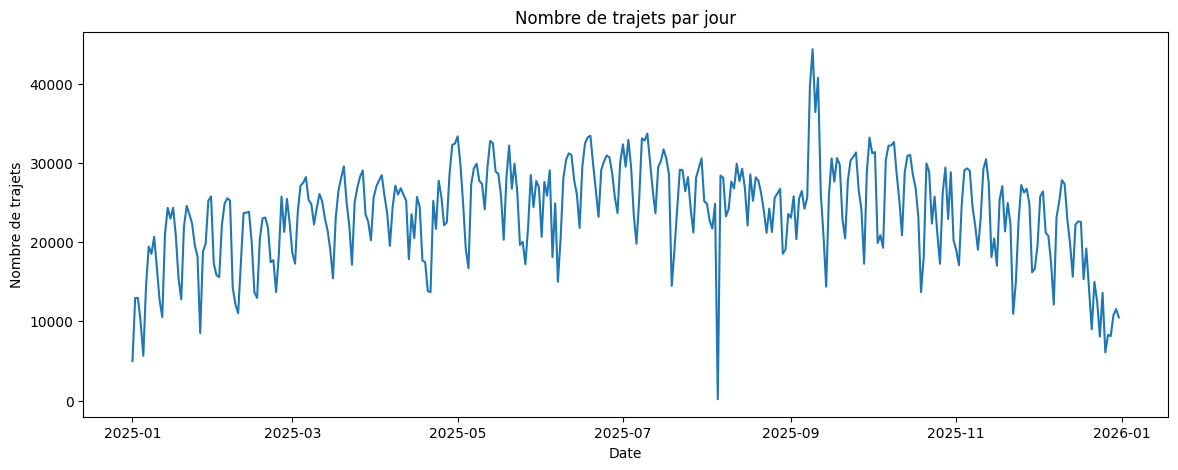

In [101]:
# la distribution du nombre de trajets par jour ;

trips["Date"] = pd.to_datetime(trips["Start date"]).dt.date

trajets_par_jour = trips.groupby("Date").size()

plt.figure(figsize=(14, 5))

plt.plot(trajets_par_jour.index, trajets_par_jour.values)

plt.xlabel("Date")
plt.ylabel("Nombre de trajets")
plt.title("Nombre de trajets par jour")

plt.show()

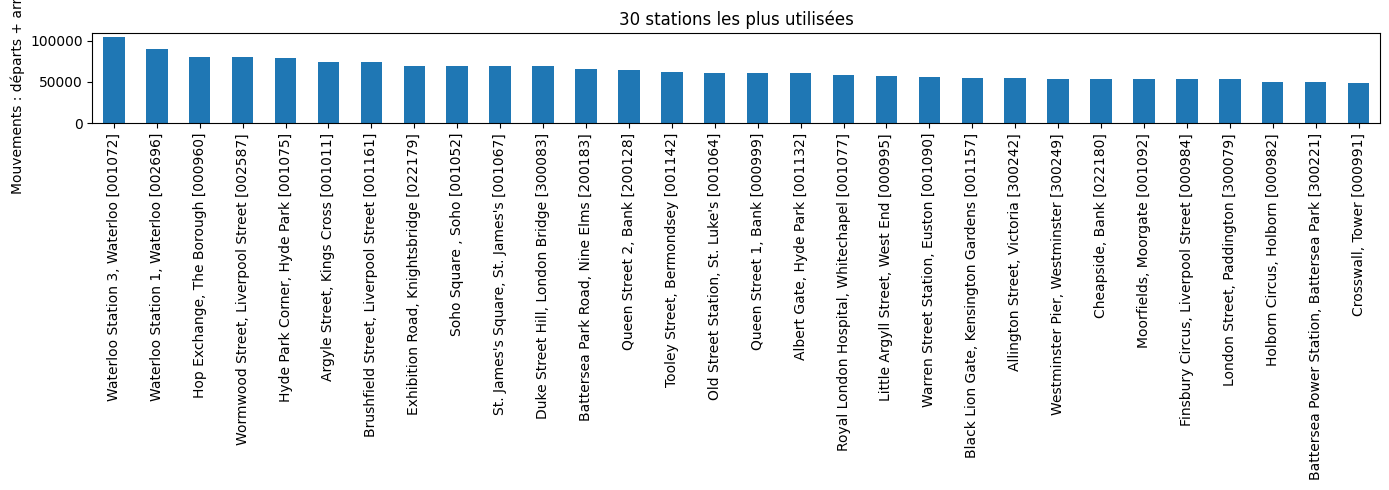

In [102]:
start = trips.groupby("Start station number").size()
end = trips.groupby("End station number").size()

top_stations = start.add(end, fill_value=0).sort_values(ascending=False).head(30)

noms_depart = (
    trips[["Start station number", "Start station"]]
    .drop_duplicates("Start station number")
    .set_index("Start station number")["Start station"]
)

etiquettes = []
for station in top_stations.index:
    etiquettes.append(str(noms_depart.get(station, station)) + " [" + str(station) + "]")

top_stations.index = etiquettes

top_stations.plot(kind="bar", figsize=(14, 5))
plt.ylabel("Mouvements : départs + arrivées")
plt.title("30 stations les plus utilisées")
plt.tight_layout()
plt.show()

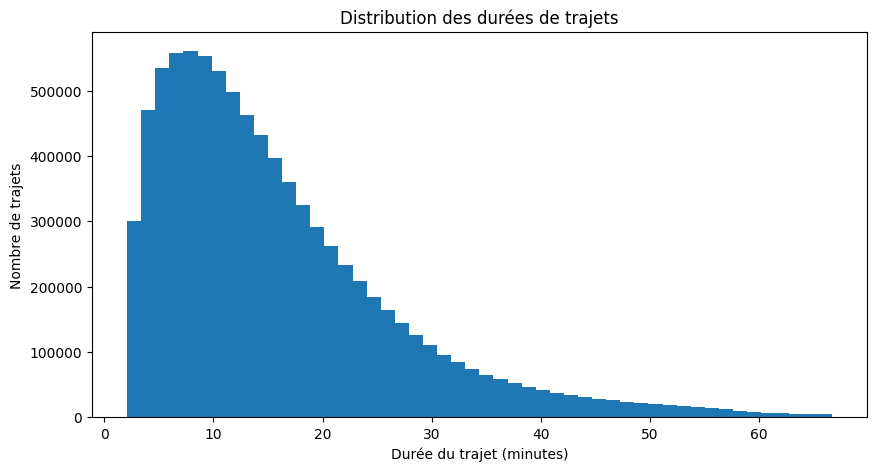

In [103]:
# la distribution des durées de trajets ;


# Limite au 99e percentile pour garder un graphique lisible
limite = trips["Duration (min)"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    trips.loc[trips["Duration (min)"] <= limite, "Duration (min)"],
    bins=50
)

plt.xlabel("Durée du trajet (minutes)")
plt.ylabel("Nombre de trajets")
plt.title("Distribution des durées de trajets")

plt.show()



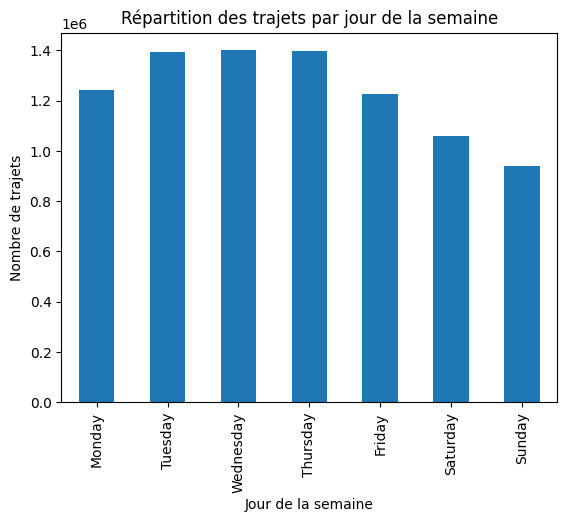

In [104]:
# la répartition des trajets selon le jour de la semaine ;

trips["Start date"] = pd.to_datetime(trips["Start date"])

ordre_jours = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

trips["Start date"].dt.day_name().value_counts().reindex(ordre_jours).plot(kind="bar")

plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre de trajets")
plt.title("Répartition des trajets par jour de la semaine")

plt.show()

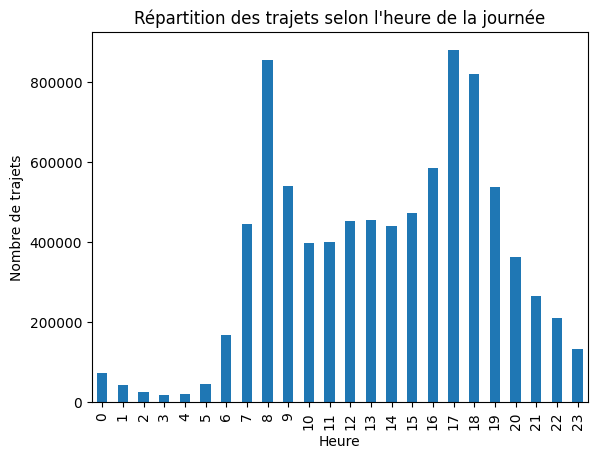

In [105]:
# la répartition des trajets selon l'heure de la journée.

trips["Start date"] = pd.to_datetime(trips["Start date"])

trips["Start date"].dt.hour.value_counts().sort_index().plot(kind="bar")

plt.xlabel("Heure")
plt.ylabel("Nombre de trajets")
plt.title("Répartition des trajets selon l'heure de la journée")

plt.show()

### Ce que montre la description générale

Après nettoyage, la base compte 8 652 819 trajets répartis sur 806 stations actives, dont
805 ont servi de point de départ. Les 24 fichiers mensuels couvrent bien les 365 jours de
l'année 2025, sans doublon de ligne ni d'identifiant de trajet.

Les distributions font apparaître deux rythmes qui structureront toute la suite : un cycle
hebdomadaire, avec un net décrochage du samedi et du dimanche, et un cycle journalier à
deux pics, le matin et en fin d'après-midi. C'est cette double périodicité que les profils
de stations de la partie 3 vont chercher à résumer.

## 3 Analyse des stations sans prendre en compte le réseau
Dans cette partie, les stations seront étudiées sans prendre en compte la structure du graphe originedestination.

3.1 Construction de profils de stations
Pour chaque station, construire un ensemble de features décrivant son activité. On pourra, par exemple,
calculer :
- le nombre total de trajets partant de la station ;
- le nombre total de trajets arrivant à la station ;
- le ratio entre départs et arrivées ;
- la durée moyenne des trajets partant de la station ;
- la durée moyenne des trajets arrivant à la station ;
- le nombre moyen de départs par jour ;
- le nombre moyen d'arrivées par jour ;
- la proportion de trajets exectués le matin ;
- la proportion de trajets exectués le soir ;
- la proportion de trajets exectués le week-end ;
- la variabilité journalière de l'activité ;
- la variabilité horaire de l'activité.
Construire ensuite des représentations temporelles plus fines :
- nombre de départs et d'arrivées par station et par jour ;
- nombre de départs et d'arrivées par station, par jour et par heure ;
- agrégation à l'échelle de la semaine ;
- agrégation à l'échelle du mois.
On pourra comparer plusieurs représentations d'une station : profil global, profil journalier moyen, profil
horaire moyen, profil semaine/week-end, profil mensuel.

In [106]:
# Liste des stations uniques utilisées dans les trajets

Data_station_start = trips[["Start station number"]].copy()
Data_station_end = trips[["End station number"]].copy()

# Renommer pour avoir les mêmes colonnes
Data_station_start.columns = ["Station number"]
Data_station_end.columns = ["Station number"]

# Fusion par le bas
Data_station = pd.concat(
    [Data_station_start, Data_station_end],
    ignore_index=True
)

# Suppression des doublons
Data_station = Data_station.drop_duplicates()

Data_station

,Station number
0,001043
1,300015
2,001068
3,001159
4,200048
...,...
2956604,001061
5413854,001212
7048500,300099
8446074,002635


In [107]:
# le nombre total de trajets partant de la station ;


nb_start = (
    trips.groupby("Start station number")
    .size()
    .reset_index(name="nb_start")
    .rename(columns={"Start station number": "Station number"})
)

nb_start


,Station number,nb_start
0,000959,9225
1,000960,36066
2,000961,10354
3,000962,11029
4,000963,11850
...,...,...
800,300248,12250
801,300249,26727
802,300250,11308
803,300252,14571


In [108]:
# le nombre total de trajets arrivant à la station ;

nb_end = (
    trips.groupby("End station number")
    .size()
    .reset_index(name="nb_end")
    .rename(columns={"End station number": "Station number"})
)

nb_end

,Station number,nb_end
0,000959,9440
1,000960,43803
2,000961,10436
3,000962,11814
4,000963,13822
...,...,...
801,300248,12623
802,300249,27147
803,300250,11972
804,300252,14957


In [109]:
Data_station = Data_station.merge(
    nb_start,
    how="left", 
    on="Station number"
    )

Data_station = Data_station.merge(
    nb_end,
    how="left", 
    on="Station number"
    )

Data_station["nb_start"] = Data_station["nb_start"].fillna(0)
Data_station["nb_end"] = Data_station["nb_end"].fillna(0)

print(Data_station[["nb_start", "nb_end"]].describe())

           nb_start        nb_end
count    806.000000    806.000000
mean   10735.507444  10735.507444
std     6183.535915   6564.485855
min        0.000000      9.000000
25%     6842.250000   6584.500000
50%     9667.000000   9293.000000
75%    13131.500000  13206.250000
max    53641.000000  50450.000000


In [110]:
Data_station

,Station number,nb_start,nb_end
0,001043,14903.0,14695
1,300015,13070.0,13171
2,001068,11005.0,11290
3,001159,13109.0,12527
4,200048,15487.0,16271
...,...,...,...
801,001061,4539.0,6326
802,001212,3082.0,3148
803,300099,827.0,816
804,002635,37.0,27


In [111]:
Data_station["ratio"] = (
    Data_station["nb_start"] /
    Data_station["nb_end"].replace(0, pd.NA)
)

In [112]:
Data_station

,Station number,nb_start,nb_end,ratio
0,001043,14903.0,14695,1.014154
1,300015,13070.0,13171,0.992332
2,001068,11005.0,11290,0.974756
3,001159,13109.0,12527,1.046460
4,200048,15487.0,16271,0.951816
...,...,...,...,...
801,001061,4539.0,6326,0.717515
802,001212,3082.0,3148,0.979034
803,300099,827.0,816,1.013480
804,002635,37.0,27,1.370370


In [113]:
# la durée moyenne des trajets partant de la station ;


trips_start_duration = (
    trips.groupby("Start station number")["Duration (min)"]
    .mean()
    .reset_index(name="avg_duration_start")
    .rename(columns={"Start station number": "Station number"})
)


# la durée moyenne des trajets arrivant à la station ;

trips_end_duration = (
    trips.groupby("End station number")["Duration (min)"]
    .mean()
    .reset_index(name="avg_duration_end")
    .rename(columns={"End station number": "Station number"})
)

print(trips_end_duration)
print(trips_start_duration)

    Station number  avg_duration_end
0           000959         13.640844
1           000960         16.892727
2           000961         14.580944
3           000962         13.771885
4           000963         15.935104
..             ...               ...
801         300248         19.911123
802         300249         27.162421
803         300250         22.038302
804         300252         23.334812
805         300253         15.546307

[806 rows x 2 columns]
    Station number  avg_duration_start
0           000959           13.173126
1           000960           17.197913
2           000961           14.651691
3           000962           14.467586
4           000963           15.526300
..             ...                 ...
800         300248           18.705735
801         300249           23.635019
802         300250           21.263578
803         300252           22.081948
804         300253           14.951063

[805 rows x 2 columns]


In [114]:
Data_station = Data_station.merge(
    trips_end_duration,
    how="left", 
    on="Station number"
    )

Data_station = Data_station.merge(
    trips_start_duration,
    how="left", 
    on="Station number"
    )

Data_station

,Station number,nb_start,nb_end,ratio,avg_duration_end,avg_duration_start
0,001043,14903.0,14695,1.014154,13.589609,14.159098
1,300015,13070.0,13171,0.992332,13.772552,13.230811
2,001068,11005.0,11290,0.974756,15.835768,15.141389
3,001159,13109.0,12527,1.046460,14.051908,14.339279
4,200048,15487.0,16271,0.951816,14.518624,15.423902
...,...,...,...,...,...,...
801,001061,4539.0,6326,0.717515,15.143732,16.102289
802,001212,3082.0,3148,0.979034,16.315035,16.804325
803,300099,827.0,816,1.013480,17.951434,17.168997
804,002635,37.0,27,1.370370,20.066005,19.913989


In [115]:
# le nombre moyen de départs par jour ;

trips_start_count = (
    trips.groupby("Start station number")
    .resample("D", on="Start date")
    .size()
    .groupby("Start station number")
    .mean()
    .reset_index(name="avg_departures_per_day")
    .rename(columns={"Start station number": "Station number"})
)


# le nombre moyen d'arrivées par jour ;

trips_end_count = (
    trips.groupby("End station number")
    .resample("D", on="End date")
    .size()
    .groupby("End station number")
    .mean()
    .reset_index(name="avg_arrivals_per_day")
    .rename(columns={"End station number": "Station number"})
)

C:\Users\conta\AppData\Local\Temp\ipykernel_8556\2862326428.py:6: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .size()
C:\Users\conta\AppData\Local\Temp\ipykernel_8556\2862326428.py:19: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .size()


In [116]:
Data_station = Data_station.merge(
    trips_start_count,
    how="left", 
    on="Station number"
    )

Data_station = Data_station.merge(
    trips_end_count,
    how="left", 
    on="Station number"
    )

Data_station

,Station number,nb_start,nb_end,ratio,avg_duration_end,avg_duration_start,avg_departures_per_day,avg_arrivals_per_day
0,001043,14903.0,14695,1.014154,13.589609,14.159098,40.830137,40.260274
1,300015,13070.0,13171,0.992332,13.772552,13.230811,35.808219,35.986339
2,001068,11005.0,11290,0.974756,15.835768,15.141389,30.150685,30.931507
3,001159,13109.0,12527,1.046460,14.051908,14.339279,35.915068,34.226776
4,200048,15487.0,16271,0.951816,14.518624,15.423902,42.430137,44.578082
...,...,...,...,...,...,...,...,...
801,001061,4539.0,6326,0.717515,15.143732,16.102289,21.013889,29.287037
802,001212,3082.0,3148,0.979034,16.315035,16.804325,22.661765,23.147059
803,300099,827.0,816,1.013480,17.951434,17.168997,12.921875,12.750000
804,002635,37.0,27,1.370370,20.066005,19.913989,5.285714,3.375000


In [117]:
# la proportion de trajets effectués le matin ;

morning_start = trips[
    (trips["Start date"].dt.hour >= 6) &
    (trips["Start date"].dt.hour < 12)
]

morning_start_ratio = (
    morning_start.groupby("Start station number").size()
    /
    trips.groupby("Start station number").size()
).reset_index(name="prop_morning_start")


morning_end = trips[
    (trips["End date"].dt.hour >= 6) &
    (trips["End date"].dt.hour < 12)
]

morning_end_ratio = (
    morning_end.groupby("End station number").size()
    /
    trips.groupby("End station number").size()
).reset_index(name="prop_morning_end")


# la proportion de trajets effectués le soir ;

evening_start = trips[
    (trips["Start date"].dt.hour >= 16) &
    (trips["Start date"].dt.hour < 24)
]

evening_start_ratio = (
    evening_start.groupby("Start station number").size()
    /
    trips.groupby("Start station number").size()
).reset_index(name="prop_evening_start")


evening_end = trips[
    (trips["End date"].dt.hour >= 16) &
    (trips["End date"].dt.hour < 24)
]

evening_end_ratio = (
    evening_end.groupby("End station number").size()
    /
    trips.groupby("End station number").size()
).reset_index(name="prop_evening_end")

In [118]:
morning_start_ratio = morning_start_ratio.rename(
    columns={"Start station number": "Station number"}
)

morning_end_ratio = morning_end_ratio.rename(
    columns={"End station number": "Station number"}
)

evening_start_ratio = evening_start_ratio.rename(
    columns={"Start station number": "Station number"}
)

evening_end_ratio = evening_end_ratio.rename(
    columns={"End station number": "Station number"}
)

In [119]:
Data_station = Data_station.merge(morning_start_ratio, on="Station number", how="left")
Data_station = Data_station.merge(morning_end_ratio, on="Station number", how="left")
Data_station = Data_station.merge(evening_start_ratio, on="Station number", how="left")
Data_station = Data_station.merge(evening_end_ratio, on="Station number", how="left")

Data_station

,Station number,nb_start,nb_end,ratio,avg_duration_end,avg_duration_start,avg_departures_per_day,avg_arrivals_per_day,prop_morning_start,prop_morning_end,prop_evening_start,prop_evening_end
0,001043,14903.0,14695,1.014154,13.589609,14.159098,40.830137,40.260274,0.187815,0.719973,0.647185,0.142361
1,300015,13070.0,13171,0.992332,13.772552,13.230811,35.808219,35.986339,0.327774,0.244628,0.437720,0.524182
2,001068,11005.0,11290,0.974756,15.835768,15.141389,30.150685,30.931507,0.159019,0.583968,0.644343,0.247741
3,001159,13109.0,12527,1.046460,14.051908,14.339279,35.915068,34.226776,0.213517,0.521194,0.557708,0.289375
4,200048,15487.0,16271,0.951816,14.518624,15.423902,42.430137,44.578082,0.319042,0.511093,0.452057,0.308709
...,...,...,...,...,...,...,...,...,...,...,...,...
801,001061,4539.0,6326,0.717515,15.143732,16.102289,21.013889,29.287037,0.080635,0.806513,0.724168,0.076035
802,001212,3082.0,3148,0.979034,16.315035,16.804325,22.661765,23.147059,0.462687,0.170902,0.375406,0.613405
803,300099,827.0,816,1.013480,17.951434,17.168997,12.921875,12.750000,0.106409,0.348039,0.611850,0.272059
804,002635,37.0,27,1.370370,20.066005,19.913989,5.285714,3.375000,0.513514,0.185185,0.216216,0.481481


In [120]:
# Proportion de trajets effectués le week-end

# Côté départ
weekend_start_ratio = (
    trips[trips["Start date"].dt.weekday >= 5]
    .groupby("Start station number")
    .size()
    .div(
        trips.groupby("Start station number").size()
    )
    .reset_index(name="prop_weekend_start")
    .rename(columns={"Start station number": "Station number"})
)

# Côté arrivée
weekend_end_ratio = (
    trips[trips["End date"].dt.weekday >= 5]
    .groupby("End station number")
    .size()
    .div(
        trips.groupby("End station number").size()
    )
    .reset_index(name="prop_weekend_end")
    .rename(columns={"End station number": "Station number"})
)

In [121]:
Data_station = Data_station.merge(
    weekend_start_ratio,
    on="Station number",
    how="left"
)

Data_station = Data_station.merge(
    weekend_end_ratio,
    on="Station number",
    how="left"
)

In [122]:
# Une absence de trajet sur un créneau vaut zéro, à condition que la station
# ait des trajets par ailleurs. Sans aucun trajet, la proportion reste indéfinie.
for periode in ["morning", "evening", "weekend"]:
    for sens, total in [("start", "nb_start"), ("end", "nb_end")]:
        col = "prop_" + periode + "_" + sens
        masque = Data_station[total] > 0
        Data_station.loc[masque, col] = Data_station.loc[masque, col].fillna(0)


# ---------- Ratios globaux ----------
Data_station["prop_morning"] = (
    Data_station["prop_morning_start"] + Data_station["prop_morning_end"]) / 2

Data_station["prop_evening"] = (
    Data_station["prop_evening_start"] + Data_station["prop_evening_end"]) / 2

Data_station["prop_weekend"] = (
    Data_station["prop_weekend_start"] + Data_station["prop_weekend_end"]) / 2

print(Data_station[["prop_morning", "prop_evening", "prop_weekend"]].describe())

       prop_morning  prop_evening  prop_weekend
count    805.000000    805.000000    805.000000
mean       0.313240      0.450080      0.237396
std        0.044364      0.032858      0.060435
min        0.170232      0.331284      0.031226
25%        0.285214      0.431357      0.208806
50%        0.313348      0.449749      0.244280
75%        0.337852      0.470801      0.271716
max        0.456357      0.585894      0.457529


In [123]:
# Variabilité journalière : les jours sans départ comptent pour zéro
daily_variability = (
    trips.set_index("Start date")
    .groupby("Start station number")["Number"]
    .resample("D")
    .size()
    .groupby(level=0)
    .std()
    .reset_index(name="daily_variability")
    .rename(columns={"Start station number": "Station number"})
)

# Variabilité horaire : les 24 heures sont toutes représentées
comptages_horaires = (
    trips.groupby([
        "Start station number",
        trips["Start date"].dt.hour.rename("heure")
    ])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

hourly_variability = (
    comptages_horaires.std(axis=1)
    .rename("hourly_variability")
    .reset_index()
    .rename(columns={"Start station number": "Station number"})
)

print(daily_variability["daily_variability"].describe())
print(hourly_variability["hourly_variability"].describe())

count    805.000000
mean      11.364340
std        7.701393
min        2.413807
25%        7.211718
50%        9.525722
75%       13.306540
max      100.941387
Name: daily_variability, dtype: float64
count     805.000000
mean      403.618603
std       310.529278
min         1.887699
25%       243.157118
50%       342.242181
75%       494.123437
max      5377.732628
Name: hourly_variability, dtype: float64


In [124]:
hourly_variability

,Station number,hourly_variability
0,000959,328.112098
1,000960,1140.950262
2,000961,381.439712
3,000962,395.908968
4,000963,513.116077
...,...,...
800,300248,372.390622
801,300249,1034.228291
802,300250,519.350905
803,300252,575.378236


In [125]:
Data_station = Data_station.merge(
    daily_variability,
    on="Station number",
    how="left"
)

Data_station = Data_station.merge(
    hourly_variability,
    on="Station number",
    how="left"
)

In [126]:
Data_station

,Station number,nb_start,nb_end,ratio,avg_duration_end,avg_duration_start,avg_departures_per_day,avg_arrivals_per_day,prop_morning_start,prop_morning_end,prop_evening_start,prop_evening_end,prop_weekend_start,prop_weekend_end,prop_morning,prop_evening,prop_weekend,daily_variability,hourly_variability
0,001043,14903.0,14695,1.014154,13.589609,14.159098,40.830137,40.260274,0.187815,0.719973,0.647185,0.142361,0.094075,0.092480,0.453894,0.394773,0.093278,22.010454,747.375959
1,300015,13070.0,13171,0.992332,13.772552,13.230811,35.808219,35.986339,0.327774,0.244628,0.437720,0.524182,0.255853,0.247058,0.286201,0.480951,0.251456,9.382966,338.819551
2,001068,11005.0,11290,0.974756,15.835768,15.141389,30.150685,30.931507,0.159019,0.583968,0.644343,0.247741,0.174012,0.175199,0.371493,0.446042,0.174606,12.080171,534.915920
3,001159,13109.0,12527,1.046460,14.051908,14.339279,35.915068,34.226776,0.213517,0.521194,0.557708,0.289375,0.135556,0.129081,0.367356,0.423542,0.132318,16.817407,514.355906
4,200048,15487.0,16271,0.951816,14.518624,15.423902,42.430137,44.578082,0.319042,0.511093,0.452057,0.308709,0.135275,0.132260,0.415068,0.380383,0.133767,19.610175,601.343964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801,001061,4539.0,6326,0.717515,15.143732,16.102289,21.013889,29.287037,0.080635,0.806513,0.724168,0.076035,0.053095,0.038413,0.443574,0.400102,0.045754,14.432354,322.853219
802,001212,3082.0,3148,0.979034,16.315035,16.804325,22.661765,23.147059,0.462687,0.170902,0.375406,0.613405,0.161259,0.153431,0.316794,0.494405,0.157345,14.599960,129.750234
803,300099,827.0,816,1.013480,17.951434,17.168997,12.921875,12.750000,0.106409,0.348039,0.611850,0.272059,0.237001,0.242647,0.227224,0.441954,0.239824,6.367838,26.454192
804,002635,37.0,27,1.370370,20.066005,19.913989,5.285714,3.375000,0.513514,0.185185,0.216216,0.481481,0.189189,0.185185,0.349349,0.348849,0.187187,3.302236,1.887699




Construire ensuite des représentations temporelles plus fines :


- agrégation à l'échelle de la semaine ;
- agrégation à l'échelle du mois.
On pourra comparer plusieurs représentations d'une station : profil global, profil journalier moyen, profil
horaire moyen, profil semaine/week-end, profil mensuel.

In [127]:
# nombre de départs et d'arrivées par station et par jour ;

# Départs par station et par jour
depart_jour = (
    trips.groupby([
        "Start station number",
        trips["Start date"].dt.date
    ])
    .size()
    .reset_index(name="nb_depart")
    .rename(columns={
        "Start station number": "Station number",
        "Start date": "Date"
    })
)

# Arrivées par station et par jour
arrivee_jour = (
    trips.groupby([
        "End station number",
        trips["End date"].dt.date
    ])
    .size()
    .reset_index(name="nb_arrivee")
    .rename(columns={
        "End station number": "Station number",
        "End date": "Date"
    })
)

# Fusion
station_jour = depart_jour.merge(
    arrivee_jour,
    on=["Station number", "Date"],
    how="outer"
).fillna(0)

In [128]:
station_jour

,Station number,Date,nb_depart,nb_arrivee
0,000959,2025-01-01,3.0,6.0
1,000959,2025-01-02,14.0,18.0
2,000959,2025-01-03,12.0,19.0
3,000959,2025-01-04,15.0,11.0
4,000959,2025-01-05,2.0,4.0
...,...,...,...,...
290653,300253,2025-12-27,12.0,19.0
290654,300253,2025-12-28,15.0,15.0
290655,300253,2025-12-29,13.0,21.0
290656,300253,2025-12-30,22.0,15.0


In [129]:
# nombre de départs et d'arrivées par station, par jour et par heure ;
#  Départs par station, jour et heure
depart_jour_heure = (
    trips.groupby([
        "Start station number",
        trips["Start date"].dt.date.rename("Date"),
        trips["Start date"].dt.hour.rename("Hour")
    ])
    .size()
    .reset_index(name="nb_depart")
    .rename(columns={"Start station number": "Station number"})
)

# Arrivées par station, jour et heure
arrivee_jour_heure = (
    trips.groupby([
        "End station number",
        trips["End date"].dt.date.rename("Date"),
        trips["End date"].dt.hour.rename("Hour")
    ])
    .size()
    .reset_index(name="nb_arrivee")
    .rename(columns={"End station number": "Station number"})
)

# Fusion départs + arrivées
station_jour_heure = depart_jour_heure.merge(
    arrivee_jour_heure,
    on=["Station number", "Date", "Hour"],
    how="outer"
).fillna(0)

station_jour_heure

,Station number,Date,Hour,nb_depart,nb_arrivee
0,000959,2025-01-01,12,0.0,3.0
1,000959,2025-01-01,13,1.0,0.0
2,000959,2025-01-01,17,1.0,1.0
3,000959,2025-01-01,18,1.0,1.0
4,000959,2025-01-01,20,0.0,1.0
...,...,...,...,...,...
4343396,300253,2025-12-31,18,2.0,1.0
4343397,300253,2025-12-31,19,1.0,1.0
4343398,300253,2025-12-31,20,1.0,1.0
4343399,300253,2025-12-31,22,0.0,1.0


In [130]:
# Agrégation hebdomadaire, en distinguant les années ISO :
# la semaine 1 de 2025 et celle de 2026 ne doivent pas être confondues.
temp = station_jour.copy()
temp["Date"] = pd.to_datetime(temp["Date"])

iso = temp["Date"].dt.isocalendar()
temp["ISO_year"] = iso.year
temp["Week"] = iso.week

station_semaine = (
    temp.groupby(["Station number", "ISO_year", "Week"])[["nb_depart", "nb_arrivee"]]
    .sum()
    .reset_index()
)

station_semaine

,Station number,ISO_year,Week,nb_depart,nb_arrivee
0,000959,2025,1,46.0,58.0
1,000959,2025,2,137.0,128.0
2,000959,2025,3,151.0,162.0
3,000959,2025,4,177.0,163.0
4,000959,2025,5,163.0,171.0
...,...,...,...,...,...
42355,300253,2025,49,206.0,221.0
42356,300253,2025,50,232.0,220.0
42357,300253,2025,51,152.0,161.0
42358,300253,2025,52,101.0,102.0


In [131]:
# Agrégation à l'échelle du mois

station_mois = (
    station_jour.assign(
        Date=pd.to_datetime(station_jour["Date"]),
        Month=pd.to_datetime(station_jour["Date"]).dt.month
    )
    .groupby(["Station number", "Month"])[["nb_depart", "nb_arrivee"]]
    .sum()
    .reset_index()
)

station_mois

,Station number,Month,nb_depart,nb_arrivee
0,000959,1,649.0,650.0
1,000959,2,595.0,616.0
2,000959,3,806.0,834.0
3,000959,4,784.0,803.0
4,000959,5,961.0,946.0
...,...,...,...,...
9608,300253,8,991.0,1025.0
9609,300253,9,1038.0,1082.0
9610,300253,10,948.0,967.0
9611,300253,11,904.0,924.0


### Bilan des profils construits

Chaque station est maintenant décrite par un ensemble de variables : volumes de départs et
d'arrivées, durées moyennes, proportions de trajets le matin, le soir et le week-end,
déséquilibres entre départs et arrivées, et variabilités journalière et horaire. Trois
tables temporelles complètent cette description à l'échelle du jour, de l'heure, de la
semaine et du mois.

Une précaution a été prise sur les valeurs manquantes : l'absence de trajet sur un créneau
vaut zéro dès lors que la station a des trajets par ailleurs, alors qu'une station sans
aucun trajet reste indéfinie. La variabilité journalière intègre par ailleurs les jours
sans départ, et la variabilité horaire les 24 heures de la journée.

Ces variables restent liées entre elles, en particulier au volume d'activité. La réduction
de dimension va permettre d'en mesurer la redondance.

## 3.2 Réduction de dimension
Appliquer les méthodes de réduction de dimension vues en cours aux profils de stations. On utilisera au
moins l'ACP et une méthode non linéaire. Questions à discuter éventuellement :
- Les premières composantes de l'ACP sont-elles interprétables ?
- Les stations se répartissent-elles selon un gradient clair ?
- Observe-t-on des groupes naturels de stations ?
- Les visualisations non linéaires mettent-elles en évidence une structure plus nette que l'ACP?
- Certaines stations apparaissent-elles comme isolées ou atypiques ?

In [132]:
import numpy as np

# Volume en log : une seule variable d'intensité
Data_station["log_volume"] = np.log1p(Data_station["nb_start"])

# Déséquilibre matin / soir.
# On reconstitue les comptages avant de faire le rapport : les proportions de
# départ et d'arrivée n'ont pas le même dénominateur.
# Positif : plus de départs que d'arrivées sur le créneau.
# Négatif : plus d'arrivées. Proche de zéro : flux équilibrés.
for periode, nom in [("morning", "matin"), ("evening", "soir")]:
    dep = Data_station["prop_" + periode + "_start"] * Data_station["nb_start"]
    arr = Data_station["prop_" + periode + "_end"] * Data_station["nb_end"]
    Data_station["imb_" + nom] = (dep - arr) / (dep + arr).replace(0, np.nan)

print(Data_station[["imb_matin", "imb_soir"]].describe())

# Stations trop peu actives écartées de l'analyse
Data_station = Data_station[Data_station["nb_start"] >= 200]
Data_station = Data_station.reset_index(drop=True)

print("Stations retenues :", len(Data_station))

        imb_matin    imb_soir
count  805.000000  805.000000
mean     0.100222   -0.050060
std      0.434907    0.273048
min     -0.900479   -0.834402
25%     -0.224342   -0.265613
50%      0.212100   -0.113421
75%      0.470082    0.133424
max      0.921741    0.753031
Stations retenues : 804


Valeurs manquantes par variable :
log_volume            0
avg_duration_start    0
prop_morning          0
prop_evening          0
prop_weekend          0
imb_matin             0
imb_soir              0
daily_variability     0
hourly_variability    0
dtype: int64
Variance expliquée : [0.38055148 0.21505602]
Variance totale : 0.5956075002067119
                        PCA1      PCA2
log_volume          0.356298 -0.352155
avg_duration_start -0.035524 -0.341300
prop_morning        0.253094  0.523769
prop_evening       -0.163186 -0.357961
prop_weekend       -0.369815 -0.405208
imb_matin          -0.373737 -0.025251
imb_soir            0.374936  0.065135
daily_variability   0.430867 -0.322705
hourly_variability  0.422419 -0.289515


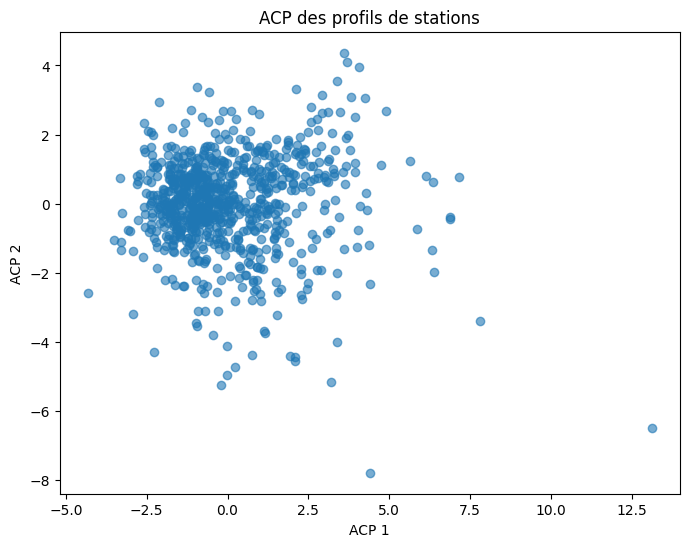

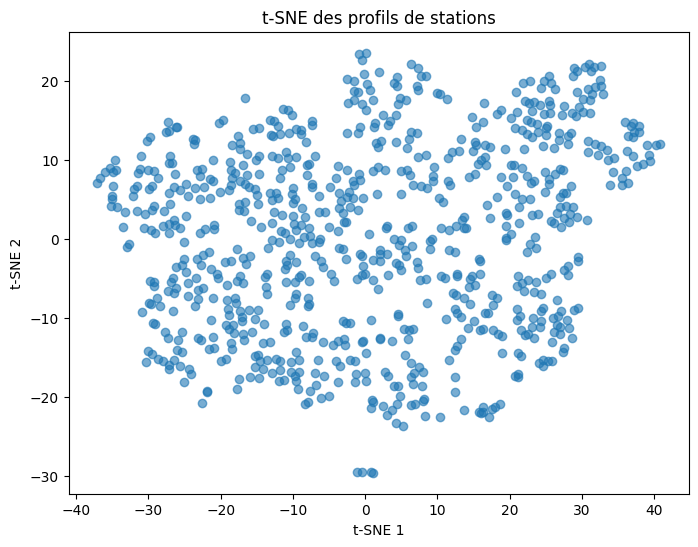

In [133]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


# Variables utilisées
features = [
    "log_volume",
    "avg_duration_start",
    "prop_morning",
    "prop_evening",
    "prop_weekend",
    "imb_matin",
    "imb_soir",
    "daily_variability",
    "hourly_variability"
]


# Préparation
X = Data_station[features].copy()

print("Valeurs manquantes par variable :")
print(X.isna().sum())

X = X.fillna(X.median())

assert np.isfinite(X.to_numpy()).all(), "La matrice contient des valeurs non finies."

# Standardisation
X_scaled = StandardScaler().fit_transform(X)

# ACP
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Data_station["PCA1"] = X_pca[:, 0]
Data_station["PCA2"] = X_pca[:, 1]

print("Variance expliquée :", pca.explained_variance_ratio_)
print("Variance totale :", pca.explained_variance_ratio_.sum())

# Contribution des variables
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=["PCA1", "PCA2"]
)

print(loadings)

# Plot ACP
plt.figure(figsize=(8, 6))
plt.scatter(Data_station["PCA1"], Data_station["PCA2"], alpha=0.6)
plt.xlabel("ACP 1")
plt.ylabel("ACP 2")
plt.title("ACP des profils de stations")
plt.show()

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

Data_station["TSNE1"] = X_tsne[:, 0]
Data_station["TSNE2"] = X_tsne[:, 1]

# Plot t-SNE
plt.figure(figsize=(8, 6))
plt.scatter(Data_station["TSNE1"], Data_station["TSNE2"], alpha=0.6)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE des profils de stations")
plt.show()

### Lecture de l'ACP

Les deux premiers axes expliquent 59,6 % de la variance, soit un peu moins de deux tiers
de l'information : la projection en deux dimensions reste donc partielle.

Le **premier axe** (38,1 %) oppose deux groupes de variables. D'un côté les variabilités
journalière et horaire, le volume et le déséquilibre du soir ; de l'autre le déséquilibre
du matin et la part de trajets le week-end. Il sépare ainsi les stations à fort trafic
pendulaire, qui se remplissent le matin, des stations résidentielles et de week-end.

Le **second axe** (21,5 %) est porté par la proportion de trajets le matin, opposée à la
part de week-end, à la durée moyenne et au volume. Il distingue les usages de semaine des
usages de loisir.

Aucune variable ne domine à elle seule le premier axe, contrairement à ce qu'on observerait
si le volume écrasait les autres dimensions. Le t-SNE, appliqué aux mêmes données, ne fait
pas apparaître de groupes nettement séparés, ce qui annonce la structure continue observée
au moment du clustering.

## 3.3 Clustering des stations
Appliquer au moins une méthode de clustering vue en cours aux prols des stations. Questions à discuter
éventuellement :
2
- Combien de groupes de stations semblent raisonnables ?
- Peut-on interpréter les groupes de stations ?
- Les groupes correspondent-ils à des stations résidentielles, touristiques, centrales, périphériques, ... ?
- Les clusters ont-ils une cohérence spatiale lorsqu'on les représente sur une carte ?

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Tester plusieurs nombres de clusters
scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    scores.append(score)

# Affichage du score de silhouette
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), scores, marker="o")
plt.xlabel("Nombre de clusters")
plt.ylabel("Score de silhouette")
plt.title("Choix du nombre de clusters")
plt.show()

print("Scores de silhouette :", [round(s, 3) for s in scores])



La courbe de silhouette atteint son maximum pour deux groupes, puis décroît de façon
régulière. Aucun nombre de clusters ne s'impose donc par ce seul critère.

Nous retenons **k = 4** comme compromis : la perte de séparation reste limitée par
rapport à k = 2, et quatre groupes permettent une interprétation nettement plus riche
qu'une simple opposition binaire. Le niveau absolu du score, modéré, invite à lire les
frontières entre clusters comme graduelles plutôt que comme des séparations nettes.

In [ ]:

# Nombre de clusters retenu
k = 4

# Clustering final
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

Data_station["cluster"] = kmeans.fit_predict(X_scaled)

# Visualisation sur l'ACP
plt.figure(figsize=(8, 6))

plt.scatter(
    Data_station["PCA1"],
    Data_station["PCA2"],
    c=Data_station["cluster"],
    alpha=0.7
)

plt.xlabel("ACP 1")
plt.ylabel("ACP 2")
plt.title("Clusters de stations sur le plan ACP")

plt.show()

# Nombre de stations par cluster
print(Data_station["cluster"].value_counts().sort_index())

# Profil moyen de chaque cluster
profil_clusters = (
    Data_station
    .groupby("cluster")[features]
    .mean()
)

display(profil_clusters.round(3))

# Volumes réels par cluster : ne pas lire une moyenne de log_volume
# comme une moyenne arithmétique du nombre de départs
display(
    Data_station.groupby("cluster")["nb_start"]
    .agg(["count", "mean", "median"])
    .round(1)
)

### Interprétation des quatre groupes

Les variables `imb_matin` et `imb_soir`, qui mesurent l'excédent de départs ou d'arrivées
sur un créneau, séparent nettement les clusters et permettent de les nommer.

Le **cluster 1** rassemble 479 stations, soit près de 60 % du réseau. Son déséquilibre
matinal est le seul nettement positif (+0,38) et son déséquilibre du soir le seul
nettement négatif (−0,22) : ces stations se vident le matin et se remplissent le soir.
C'est le profil **résidentiel**, avec un volume moyen de 8 600 départs annuels, le plus
faible des quatre.

Le **cluster 2** (181 stations) en est le miroir exact : −0,40 le matin, +0,28 le soir,
et la plus faible part de trajets le week-end après le cluster 0 (17 %). Ce sont les
**pôles d'emploi**, où l'on arrive le matin et d'où l'on repart le soir.

Le **cluster 0** ne compte que 24 stations mais se distingue par son intensité : 29 800
départs annuels en moyenne, une variabilité horaire trois fois supérieure aux autres
(1 501) et seulement 14,7 % de trajets le week-end. Ce sont les **grands hubs**, gares et
échangeurs à trafic pendulaire massif.

Le **cluster 3** (120 stations) affiche la durée moyenne la plus longue (20,9 minutes
contre 16 ailleurs), la plus forte part de week-end (29,1 %) et la plus faible activité
matinale. Ce profil de trajet long et de fin de semaine correspond à un usage
**récréatif ou touristique**.

Les quatre groupes recouvrent donc les catégories attendues, et se distinguent par leur
rythme d'usage autant que par leur volume.

In [ ]:
import folium
import numpy as np

# Noms des clusters
noms = ["Grands hubs", "Résidentiel", "Pôles d'emploi", "Loisir / touristique"]
couleurs = ["blue", "red", "black", "green"]

# Coordonnées des stations
geo = Data_station.merge(
    GPS_Point,
    left_on="Station number",
    right_on="terminal_name",
    how="left"
)
geo = geo.dropna(subset=["latitude", "longitude"])


# ---------- Taille des points : mouvements par jour, échelle logarithmique ----------
geo["mouvements_jour"] = (
    geo["avg_departures_per_day"].fillna(0) + geo["avg_arrivals_per_day"].fillna(0)
)

v = np.log1p(geo["mouvements_jour"])
v_min = v.min()
v_max = v.max()

rayon_min = 2.0
rayon_max = 11.0

geo["rayon"] = rayon_min + (rayon_max - rayon_min) * (v - v_min) / (v_max - v_min)

print("Mouvements par jour :",
      round(geo["mouvements_jour"].min(), 1), "→",
      round(geo["mouvements_jour"].max(), 1),
      "| médiane", round(geo["mouvements_jour"].median(), 1))


# ---------- Carte ----------
carte = folium.Map(location=[51.5074, -0.1278], zoom_start=12)

# Les plus petites stations dessinées en premier, pour que les grosses restent visibles
geo = geo.sort_values("mouvements_jour")

for _, row in geo.iterrows():
    c = int(row["cluster"])
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=row["rayon"],
        color=couleurs[c],
        fill=True,
        fill_color=couleurs[c],
        fill_opacity=0.6,
        weight=1,
        popup=f'{row["station_name"]} — {noms[c]}<br>'
              f'{round(row["mouvements_jour"], 1)} mouvements par jour'
    ).add_to(carte)


# ---------- Légende ----------
legende = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
            background-color: white; border: 2px solid grey; border-radius: 5px;
            padding: 10px 12px; font-size: 14px; font-family: sans-serif;">
<b>Clusters de stations</b><br>
"""

for i in range(len(noms)):
    legende = legende + ('<span style="color:' + couleurs[i]
                         + '; font-size:18px;">&#9679;</span> ' + noms[i] + "<br>")

# Repères de taille
legende = legende + '<div style="margin-top:10px;"><b>Mouvements par jour</b><br>'

for valeur in [5, 30, 150]:
    r = rayon_min + (rayon_max - rayon_min) * (np.log1p(valeur) - v_min) / (v_max - v_min)
    taille = int(round(2 * r))
    legende = legende + (
        '<div style="margin:4px 0; display:flex; align-items:center;">'
        '<span style="display:inline-block; width:24px; text-align:center;">'
        '<span style="display:inline-block; width:' + str(taille) + 'px; height:' + str(taille) + 'px;'
        ' border:1px solid #666; border-radius:50%; background:#ccc;"></span></span>'
        '<span style="margin-left:8px;">' + str(valeur) + '</span></div>'
    )

legende = legende + '<div style="color:#888; font-size:11px;">échelle logarithmique</div></div></div>'

carte.get_root().html.add_child(folium.Element(legende))

carte.save("clusters_stations.html")

carte

La carte confirme que les clusters n'ont pas de cohérence spatiale marquée : les quatre
profils se mélangent dans presque tous les quartiers. Le cluster récréatif se concentre
toutefois autour des grands parcs, et les grands hubs se repèrent immédiatement à leur
taille, la surface des points étant proportionnelle au nombre de mouvements quotidiens en
échelle logarithmique.

Cette absence de structure géographique n'est pas un défaut : elle signifie simplement que
le rythme d'usage d'une station ne se déduit pas de sa position. C'est précisément ce que
la partie 4 va aborder sous un autre angle.

## 3.4 Détection d'anomalies
À partir des profils de stations, utiliser au moins une méthode de détection d'anomalies vue en cours. On
pourra, par exemple, rechercher :
- des stations avec un ratio départs/arrivées extrême ;
- des stations avec une activité très faible ou très forte ;
- des stations dont le profil horaire est atypique ;
- des stations très diférentes de leur voisinage dans l'espace réduit ;
- des stations mal représentées par les clusters ;
- des stations avec une variabilité temporelle inhabituelle.
Les anomalies identifiées devront être interprétées : s'agit-il probablement d'erreurs, de stations particulières,
de stations très touristiques, de stations en bordure du réseau, ou de comportements rares mais plausibles ?

In [137]:
noms_stations = GPS_Point[["terminal_name", "station_name"]]

Data_station = Data_station.merge(
    noms_stations,
    left_on="Station number",
    right_on="terminal_name",
    how="left"
)

noms_stations

,terminal_name,station_name
0,001023,"River Street , Clerkenwell"
1,001018,"Phillimore Gardens, Kensington"
2,001012,"Christopher Street, Liverpool Street"
3,001013,"St. Chad's Street, King's Cross"
4,003420,"Sedding Street, Sloane Square"
...,...,...
795,200145,"Gloucester Avenue, Camden Town"
796,001188,"London Zoo Car Park, The Regent's Park"
797,001068,"Norton Folgate, Liverpool Street"
798,300066,"Horse Guards Avenue, Westminster"


In [138]:
# Contrôle : les stations dont l'identifiant est absent du référentiel BikePoint.
# Une période d'activité courte signale un identifiant encore corrompu ;
# une période couvrant l'année entière signale une station absente du
# référentiel de 2026, sans que l'on puisse conclure sur son statut en 2025.
sans_nom = Data_station[Data_station["station_name"].isna()]

print("Stations sans nom :", len(sans_nom))
print("Trajets concernés :", int(sans_nom["nb_start"].sum()))

for station in sans_nom["Station number"]:
    t = trips[trips["Start station number"] == station]
    if len(t) > 0:
        debut = t["Start date"].min().date()
        fin = t["Start date"].max().date()
        print(station, "|", debut, "→", fin, "|", len(t), "trajets")

Stations sans nom : 7
Trajets concernés : 62565
001158 | 2025-01-01 → 2025-12-31 | 8959 trajets
300232 | 2025-01-01 → 2025-11-14 | 9084 trajets
022163 | 2025-01-01 → 2025-12-31 | 15934 trajets
001152 | 2025-01-01 → 2025-12-31 | 13202 trajets
022181 | 2025-01-01 → 2025-12-31 | 5398 trajets
003478 | 2025-01-01 → 2025-12-31 | 7390 trajets
200015 | 2025-01-01 → 2025-12-31 | 2598 trajets


Sept stations n'ont pas de nom après correction des identifiants. Six ont été actives toute
l'année 2025 et une jusqu'au 14 novembre ; elles totalisent 62 565 trajets. Leur absence du
référentiel BikePoint, qui décrit l'état du réseau en 2026, ne permet pas de conclure sur
leur statut en 2025. Elles sont conservées dans l'analyse, l'absence de nom n'affectant que
l'affichage des résultats.

#### Méthode 1 : distance de Mahalanobis

Anomalies Mahalanobis (seuil 5%) : 81


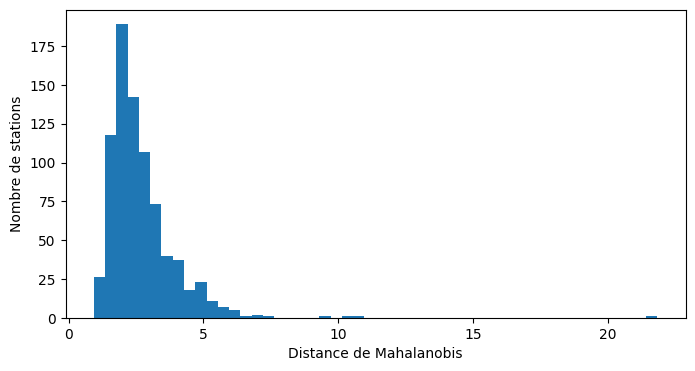

In [139]:
import numpy as np
from scipy.stats import f as loi_f
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# Même matrice que pour le clustering, pour que les résultats soient comparables
X_ano = X_scaled.copy()

n = X_ano.shape[0]
d = X_ano.shape[1]

# ---------- Méthode 1 : distance de Mahalanobis ----------
moyenne = X_ano.mean(axis=0)
S = np.cov(X_ano, rowvar=False)
S_inv = np.linalg.inv(S)

d2 = []
for i in range(n):
    ecart = X_ano[i] - moyenne
    d2.append(ecart @ S_inv @ ecart)

d2 = np.array(d2)

Data_station["mahalanobis"] = np.sqrt(d2)

# Test de Fisher, comme dans le cours
stat = d2 * n * (n - d) / ((n * n - 1) * d)
Data_station["p_mahalanobis"] = 1 - loi_f.cdf(stat, d, n - d)

print("Anomalies Mahalanobis (seuil 5%) :", (Data_station["p_mahalanobis"] < 0.05).sum())

plt.figure(figsize=(8, 4))
plt.hist(Data_station["mahalanobis"], bins=50)
plt.xlabel("Distance de Mahalanobis")
plt.ylabel("Nombre de stations")
plt.show()



La distance de Mahalanobis mesure l'éloignement d'une station au profil moyen du réseau,
en tenant compte des corrélations entre variables.

La plupart des stations se situent entre 1 et 5. La décroissance est ensuite rapide, avec
une longue traîne : quelques stations dépassent 9, dont une atteint 21,8.

Le test fondé sur la loi de Fisher signale 81 stations au seuil de 5 %, soit 10 % du
réseau. Ce test suppose une distribution gaussienne multivariée des profils, hypothèse
qui n'a pas été vérifiée ici. Le résultat doit donc se lire comme un classement du plus
atypique au moins atypique, plutôt que comme un niveau de risque garanti.

Sa limite tient à sa nature globale : une station entourée de peu de voisines mais proche
de la moyenne ne sera pas détectée. C'est ce que le LOF permet de compléter.

####  Méthode 2 : LOF 

Anomalies LOF (score > 1.6) : 11


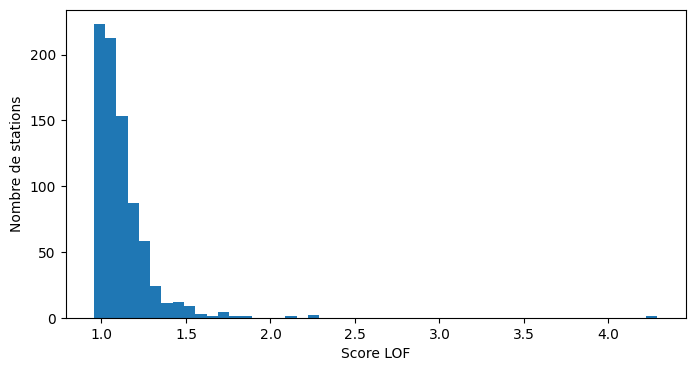

In [140]:


# ---------- Méthode 2 : LOF ----------
lof = LocalOutlierFactor(n_neighbors=10)
lof.fit_predict(X_ano)

Data_station["lof"] = -lof.negative_outlier_factor_

print("Anomalies LOF (score > 1.6) :", (Data_station["lof"] > 1.6).sum())

plt.figure(figsize=(8, 4))
plt.hist(Data_station["lof"], bins=50)
plt.xlabel("Score LOF")
plt.ylabel("Nombre de stations")
plt.show()



Le LOF compare la densité de stations autour d'une station donnée à celle observée autour
de ses dix plus proches voisines. Un score proche de 1 signifie une densité comparable ;
plus le score monte, plus la station est isolée dans l'espace des profils.

La grande majorité des stations se situent entre 1 et 1,3. La traîne est courte, avec une
valeur extrême à 4,29.

Au seuil exploratoire de 1,6, la méthode retient 11 stations. Elle est donc bien plus
sélective que Mahalanobis, et surtout elle ne cherche pas la même chose : Mahalanobis
repère les stations éloignées de la moyenne, le LOF celles qui n'ont pas de semblables.

Sa limite est la sensibilité au nombre de voisines retenu : avec neuf variables, les
distances deviennent peu discriminantes et le résultat peut changer si l'on passe de dix
à vingt voisines.

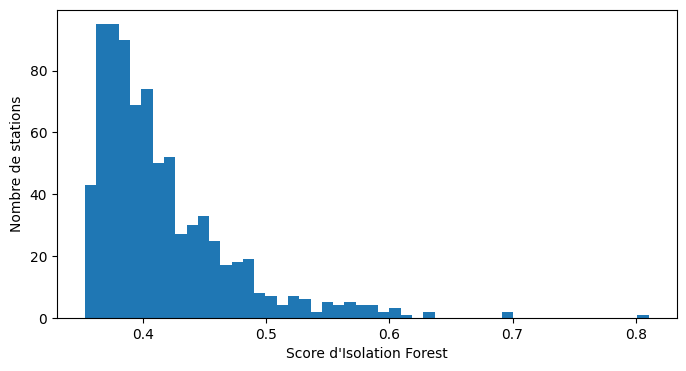

count    804.000000
mean       0.415476
std        0.054927
min        0.352894
25%        0.377403
50%        0.399696
75%        0.438336
max        0.810565
Name: iso_score, dtype: float64
Anomalies Isolation Forest (score > 0.6 ) : 9
                            station_name  nb_start     ratio  avg_duration_start  prop_weekend  imb_matin  hourly_variability  iso_score
392         Waterloo Station 3, Waterloo   53641.0  1.063251           13.179644      0.031226   0.921741         5377.732628   0.810565
210         Waterloo Station 1, Waterloo   45993.0  1.045486           14.602370      0.116905   0.606853         2664.429033   0.700390
325          Hyde Park Corner, Hyde Park   42203.0  1.152426           30.359692      0.385980  -0.057224         1618.175730   0.695983
379         Waterloo Station 2, Waterloo   22479.0  1.429507           15.013862      0.111814   0.863883         1328.354975   0.630005
734             Knightsbridge, Hyde Park    6378.0  2.683214           31.675

In [141]:
from sklearn.ensemble import IsolationForest

# ---------- Méthode 3 : Isolation Forest ----------
iso = IsolationForest(
    n_estimators=500,
    max_samples=n,          # tout l'échantillon, comme dans le cours
    random_state=42
)

iso.fit(X_ano)

# Score d'anomalie entre 0 et 1 : plus il est élevé, plus la station est atypique
Data_station["iso_score"] = -iso.score_samples(X_ano)

plt.figure(figsize=(8, 4))
plt.hist(Data_station["iso_score"], bins=50)
plt.xlabel("Score d'Isolation Forest")
plt.ylabel("Nombre de stations")
plt.show()

print(Data_station["iso_score"].describe())

# Seuil lu sur l'histogramme
seuil_iso = 0.60

print("Anomalies Isolation Forest (score >", seuil_iso, ") :",
      (Data_station["iso_score"] > seuil_iso).sum())

anomalies = Data_station[Data_station["iso_score"] > seuil_iso]
anomalies = anomalies.sort_values("iso_score", ascending=False)

print(anomalies[[
    "station_name", "nb_start", "ratio", "avg_duration_start",
    "prop_weekend", "imb_matin", "hourly_variability", "iso_score"
]].to_string())

L'Isolation Forest mesure la facilité avec laquelle une station peut être séparée du reste
du nuage par des découpages aléatoires successifs. Plus une station est vite isolée, plus
son score est élevé.

La distribution est resserrée : la moitié des stations sont sous 0,40 et les trois quarts
sous 0,44, pour un maximum à 0,81.

Au seuil exploratoire de 0,60, la méthode retient 9 stations : les trois stations de
Waterloo, quatre stations de Hyde Park et Kensington Gardens, Newgate Street et Mudchute
DLR. Sur ce jeu de variables, elle privilégie les stations combinant un fort volume et une
variabilité horaire élevée.

#### Croisement des trois méthodes

In [142]:
# ---------- Comparaison des trois méthodes ----------
Data_station["ano_maha"] = Data_station["p_mahalanobis"] < 0.05
Data_station["ano_lof"] = Data_station["lof"] > 1.6
Data_station["ano_iso"] = Data_station["iso_score"] > seuil_iso

print("Mahalanobis     :", Data_station["ano_maha"].sum())
print("LOF             :", Data_station["ano_lof"].sum())
print("Isolation Forest:", Data_station["ano_iso"].sum())

Data_station["nb_methodes"] = (Data_station["ano_maha"].astype(int)
                               + Data_station["ano_lof"].astype(int)
                               + Data_station["ano_iso"].astype(int))

print("--- Nombre de méthodes ayant détecté chaque station ---")
print(Data_station["nb_methodes"].value_counts().sort_index())

print("--- Stations détectées par les trois méthodes ---")
consensus = Data_station[Data_station["nb_methodes"] == 3]
consensus = consensus.sort_values("iso_score", ascending=False)

print(consensus[[
    "station_name", "nb_start", "prop_weekend",
    "mahalanobis", "lof", "iso_score"
]].to_string())

print("--- Stations détectées par deux méthodes ---")
deux = Data_station[Data_station["nb_methodes"] == 2]
deux = deux.sort_values("iso_score", ascending=False)

print(deux[[
    "station_name", "ano_maha", "ano_lof", "ano_iso",
    "mahalanobis", "lof", "iso_score"
]].to_string())

Mahalanobis     : 81
LOF             : 11
Isolation Forest: 9
--- Nombre de méthodes ayant détecté chaque station ---
nb_methodes
0    721
1     70
2      8
3      5
Name: count, dtype: int64
--- Stations détectées par les trois méthodes ---
                     station_name  nb_start  prop_weekend  mahalanobis       lof  iso_score
392  Waterloo Station 3, Waterloo   53641.0      0.031226    21.847169  4.290143   0.810565
210  Waterloo Station 1, Waterloo   45993.0      0.116905    10.172639  2.230526   0.700390
325   Hyde Park Corner, Hyde Park   42203.0      0.385980    10.603543  1.863404   0.695983
379  Waterloo Station 2, Waterloo   22479.0      0.111814     5.798563  1.720186   0.630005
429     Mudchute DLR, Cubitt Town    1827.0      0.436848     5.999106  1.708593   0.611112
--- Stations détectées par deux méthodes ---
                            station_name  ano_maha  ano_lof  ano_iso  mahalanobis       lof  iso_score
734             Knightsbridge, Hyde Park      True    Fals

### Comparaison des trois méthodes

Les trois méthodes retiennent des nombres très différents de stations : 81 pour
Mahalanobis, 11 pour le LOF, 9 pour l'Isolation Forest. Sur 804 stations, 721 ne sont
signalées par aucune, 70 par une seule, 8 par deux et **5 par les trois**.

Les cinq stations retenues par les trois méthodes sont les **trois stations de Waterloo**,
**Hyde Park Corner** et **Mudchute DLR**. Waterloo Station 3 domine tous les classements —
21,8 en distance de Mahalanobis, 4,29 en LOF, 0,81 en Isolation Forest — avec 53 641
départs annuels et seulement 3 % de trajets le week-end : c'est la station la plus
spécialisée du réseau. Hyde Park Corner en est l'opposé, avec un volume comparable mais
39 % de week-end et des durées deux fois plus longues. Mudchute DLR relève d'un troisième
cas : très peu active, en bordure de réseau, avec 44 % de trajets le week-end.

Les huit stations détectées par deux méthodes éclairent ce que chacune capte. Knightsbridge,
Albert Gate, Black Lion Gate et Newgate Street sortent chez Mahalanobis et l'Isolation
Forest mais pas au LOF : leur profil est extrême, mais elles ressemblent à leurs voisines
immédiates. À l'inverse, Adeline Place, South Quay East, Heron Quays DLR et Concert Hall
Approach sortent chez Mahalanobis et au LOF : peu actives et isolées dans l'espace des
profils, sans volume suffisant pour que l'Isolation Forest les repère.

Le fait qu'une station soit retenue par les trois méthodes renforce l'intérêt de l'examiner,
mais ne prouve pas qu'il s'agisse d'une anomalie au sens d'une erreur. Toutes celles
identifiées ici correspondent à des usages réels, simplement extrêmes : rabattement massif
sur une gare, promenade dans un parc, marge du service.

#### Analyse complémentaire : stations mal représentées par leur cluster

Le score de silhouette calculé station par station : une valeur négative signifie que la station ressemble davantage à un autre groupe qu'au sien.

In [143]:
from sklearn.metrics import silhouette_samples

Data_station["silhouette"] = silhouette_samples(X_scaled, Data_station["cluster"])

mal_classees = Data_station[Data_station["silhouette"] < 0]
mal_classees = mal_classees.sort_values("silhouette")

print("Stations mal représentées :", len(mal_classees))

mal_classees[[
    "station_name",
    "cluster",
    "silhouette",
    "imb_matin",
    "imb_soir",
    "prop_weekend"
]].head(20)

Stations mal représentées : 65


,station_name,cluster,silhouette,imb_matin,imb_soir,prop_weekend
275,"Westferry DLR, Limehouse",3,-0.219701,0.070147,-0.079747,0.274079
475,"Bridge Avenue, Hammersmith",3,-0.187982,0.130423,-0.083299,0.269964
146,"Central House, Aldgate",3,-0.186798,-0.035488,0.012388,0.261981
101,"Ravenscourt Park Station, Hammersmith",3,-0.150822,0.263126,-0.166116,0.268947
737,"Brick Lane Market, Shoreditch",3,-0.150325,0.079173,-0.009731,0.317976
40,"Shoreditch High Street, Shoreditch",3,-0.147000,-0.046355,-0.010835,0.273546
439,"Westminster University, Marylebone",3,-0.145325,-0.047958,0.030093,0.244663
549,"Canada Water Station, Rotherhithe",3,-0.143681,0.589883,-0.389477,0.294521
342,"Blenheim Crescent, Ladbroke Grove",3,-0.134869,0.227292,-0.151694,0.333428
541,"Blackfriars Station, St. Paul's",0,-0.124013,-0.365566,0.278957,0.127924


### Stations mal représentées par leur cluster

Le score de silhouette calculé station par station identifie 65 stations, soit 8 % du
réseau, dont la silhouette est négative : leur profil ressemble davantage à un autre
groupe qu'au leur. Ce ne sont pas des valeurs extrêmes, mais des profils intermédiaires.

La quasi-totalité appartient au **cluster récréatif**, alors que leur déséquilibre matinal
reste souvent positif — signature résidentielle. Westferry DLR, Bridge Avenue,
Ravenscourt Park, Blenheim Crescent ou Hawley Crescent sont des quartiers d'habitation dont
la part de trajets le week-end, comprise entre 26 et 35 %, suffit à les faire basculer.

Un second cas apparaît avec des stations au déséquilibre quasi nul dans les deux sens,
comme Central House à Aldgate ou Shoreditch High Street : ce sont des quartiers mixtes,
sans rythme dominant, qu'aucun cluster ne décrit vraiment.

La frontière incertaine ne sépare donc pas le résidentiel du tertiaire, nettement opposés
par leurs déséquilibres inverses, mais le résidentiel du récréatif, qui ne diffèrent que
par un gradient de fréquentation le week-end. Une silhouette négative signale une
affectation discutable dans l'espace de représentation choisi ; elle n'indique pas une
erreur dans les données.

### Vers l'analyse du réseau

La partie 3 a décrit chaque station indépendamment des autres, à partir de son propre
rythme d'activité. Cette approche ignore une information centrale : d'où viennent et où
vont les vélos.

La partie 4 reprend donc les mêmes données sous forme de graphe, où chaque liaison porte le
nombre de trajets observés entre deux stations. L'objectif est de savoir si cette
représentation fait apparaître une organisation différente de celle des profils d'usage.

# 4 Analyse des stations en prenant en compte le réseau
Dans cette partie, les flux entre stations seront utilisés explicitement pour construire une structure de
graphe.

4.1 Construction du graphe origine-destination
À partir des données brutes, construire un graphe orienté pondéré :
G = (V,E),
où :
- les n÷uds sont les stations ;
- une arête orientée i → j existe s'il y a au moins un trajet partant de la station i et arrivant à la
station j ;
- le poids wij est le nombre de trajets observés de i vers j en 2025.
Décrire le graphe obtenu : nombre de n÷uds, nombre d'arêtes, distribution des degrés entrants, distribution
des degrés sortants, distribution des poids d'arêtes, stations les plus centrales, stations avec fort déséquilibre
entre ux entrants et sortants.
Optionnel : construire éventuellement plusieurs graphes en agrégeant les ux selon diérentes périodes :
matin, après-midi, soir, nuit, semaine, week-end, mois, saison. Questions à traiter éventuellement :
- Le graphe du matin ressemble-t-il au graphe du soir ?
- Les ux changent-ils d'orientation entre le matin et le soir ?
- Le graphe du week-end a-t-il la même structure que le graphe de semaine ?
- Certaines stations changent-elles de rôle selon la période considérée ?
- Les communautés du graphe sont-elles stables dans le temps ?

### Construction de la table des flux

On agrège les trajets par couple (station de départ, station d'arrivée). Chaque ligne
correspond ainsi à une liaison orientée du réseau, et la colonne `nb_trajets` donne le
poids w<sub>ij</sub> de cette liaison, c'est-à-dire le nombre de trajets observés de la
station i vers la station j sur l'année 2025.

Cette table constitue la représentation complète du graphe origine-destination : une
liaison i → j existe dès qu'au moins un trajet a été effectué dans ce sens. Elle servira
de base à la construction du graphe orienté pondéré, puis à l'estimation du modèle de
blocs stochastiques en partie 4.2.

In [144]:
flux = (
    trips.groupby(["Start station number", "End station number"])
    .size()
    .reset_index(name="nb_trajets")
)

flux = flux.sort_values("nb_trajets", ascending=False)

print(flux.shape)
flux.head(20)

(452018, 3)


,Start station number,End station number,nb_trajets
276597,200038,200230,3433
363049,200230,200038,3144
72481,001075,001132,3021
430971,300213,300234,2850
440703,300234,300213,2750
106486,001132,001075,2703
72505,001075,001157,2514
122172,001157,001110,2385
122141,001157,001075,2308
72560,001075,001217,2263


In [145]:
# Décommenter à la première exécution si networkx n'est pas installé
# %pip install networkx

Nombre de noeuds : 806
Nombre d'arêtes : 452018
Arêtes possibles : 648830
Densité : 0.697


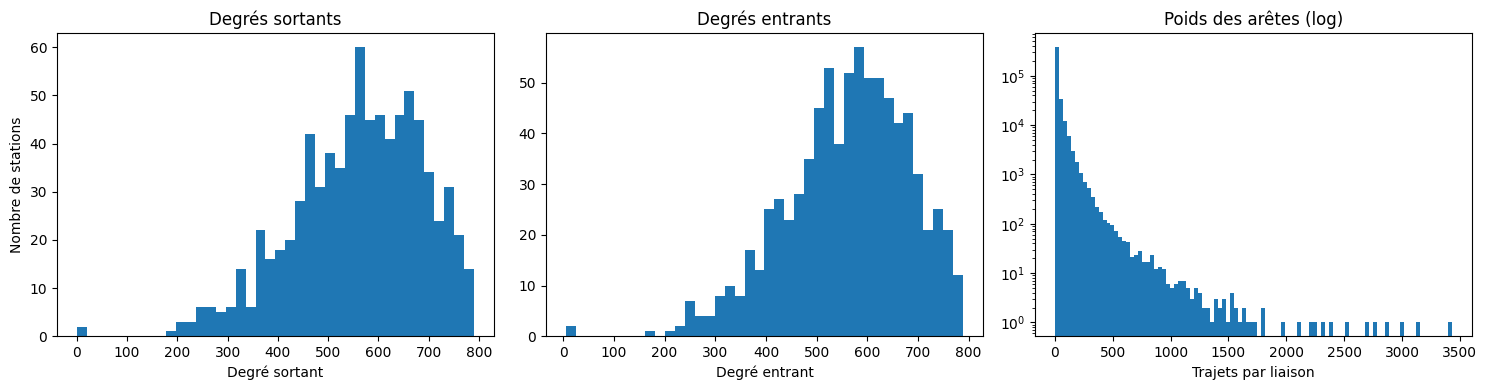

--- Degrés sortants ---
count    806.000000
mean     560.816377
std      128.293205
min        0.000000
25%      475.500000
50%      572.000000
75%      658.000000
max      790.000000
dtype: float64
--- Poids des arêtes ---
count    452018.000000
mean         19.142643
std          46.315422
min           1.000000
25%           2.000000
50%           6.000000
75%          18.000000
max        3433.000000
Name: nb_trajets, dtype: float64
Liaisons à moins de 10 trajets : 276391 sur 452018
--- Liaisons les plus fréquentes ---
                                   depart                                arrivee  nb_trajets
0                      Ackroyd Drive, Bow                Maplin Street, Mile End        3433
1                 Maplin Street, Mile End                     Ackroyd Drive, Bow        3144
2             Hyde Park Corner, Hyde Park                 Albert Gate, Hyde Park        3021
3               Monier Road, Hackney Wick           Stratford Station, Stratford        2850
4     

In [146]:
import networkx as nx

# ---------- 1. Construction du graphe ----------
G = nx.DiGraph()

for i, row in flux.iterrows():
    G.add_edge(row["Start station number"],
               row["End station number"],
               weight=row["nb_trajets"])


# ---------- 2. Taille du graphe ----------
n = G.number_of_nodes()

print("Nombre de noeuds :", n)
print("Nombre d'arêtes :", G.number_of_edges())
print("Arêtes possibles :", n * (n - 1))
print("Densité :", round(nx.density(G), 3))


# ---------- 3. Degrés et poids ----------
degres_out = []
degres_in = []

for station in G.nodes():
    degres_out.append(G.out_degree(station))
    degres_in.append(G.in_degree(station))

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(degres_out, bins=40)
plt.xlabel("Degré sortant")
plt.ylabel("Nombre de stations")
plt.title("Degrés sortants")

plt.subplot(1, 3, 2)
plt.hist(degres_in, bins=40)
plt.xlabel("Degré entrant")
plt.title("Degrés entrants")

plt.subplot(1, 3, 3)
plt.hist(flux["nb_trajets"], bins=100, log=True)
plt.xlabel("Trajets par liaison")
plt.title("Poids des arêtes (log)")

plt.tight_layout()
plt.show()

print("--- Degrés sortants ---")
print(pd.Series(degres_out).describe())

print("--- Poids des arêtes ---")
print(flux["nb_trajets"].describe())
print("Liaisons à moins de 10 trajets :",
      (flux["nb_trajets"] < 10).sum(), "sur", len(flux))


# ---------- 4. Liaisons les plus fréquentes ----------
liaisons = flux.sort_values("nb_trajets", ascending=False).head(15)

liaisons = liaisons.merge(noms_stations, left_on="Start station number",
                          right_on="terminal_name", how="left")
liaisons = liaisons.rename(columns={"station_name": "depart"})

liaisons = liaisons.merge(noms_stations, left_on="End station number",
                          right_on="terminal_name", how="left")
liaisons = liaisons.rename(columns={"station_name": "arrivee"})

print("--- Liaisons les plus fréquentes ---")
print(liaisons[["depart", "arrivee", "nb_trajets"]].to_string())


# ---------- 5. Stations les plus centrales ----------
force_out = dict(G.out_degree(weight="weight"))
force_in = dict(G.in_degree(weight="weight"))
pagerank = nx.pagerank(G, weight="weight")

centralites = pd.DataFrame({
    "Station number": list(pagerank.keys()),
    "force_out": list(force_out.values()),
    "force_in": list(force_in.values()),
    "pagerank": list(pagerank.values())
})

centralites = centralites.merge(noms_stations,
                                left_on="Station number",
                                right_on="terminal_name",
                                how="left")

print("--- Stations les plus centrales ---")
print(centralites.sort_values("pagerank", ascending=False)[
    ["station_name", "force_out", "force_in", "pagerank"]].head(15).to_string())


# ---------- 6. Déséquilibre entrants / sortants ----------
centralites["desequilibre"] = (
    (centralites["force_out"] - centralites["force_in"]) /
    (centralites["force_out"] + centralites["force_in"])
)

print("--- Stations émettrices (plus de départs) ---")
print(centralites.sort_values("desequilibre", ascending=False)[
    ["station_name", "force_out", "force_in", "desequilibre"]].head(10).to_string())

print("--- Stations réceptrices (plus d'arrivées) ---")
print(centralites.sort_values("desequilibre")[
    ["station_name", "force_out", "force_in", "desequilibre"]].head(10).to_string())

In [147]:
moyenne = flux["nb_trajets"].mean()
variance = flux["nb_trajets"].var()

print("Moyenne :", round(moyenne, 2))
print("Variance :", round(variance, 2))
print("Indice de dispersion :", round(variance / moyenne, 1))

Moyenne : 19.14
Variance : 2145.12
Indice de dispersion : 112.1


In [148]:
import folium
import numpy as np

# ---------- 1. Les 200 liaisons les plus fortes, deux sens confondus ----------
# Les deux directions sont additionnées sur la totalité des liaisons AVANT
# la sélection : une présélection fausserait le classement des paires.
a_ser = flux["Start station number"].astype(str)
b_ser = flux["End station number"].astype(str)

petit = a_ser.where(a_ser <= b_ser, b_ser)
grand = b_ser.where(a_ser <= b_ser, a_ser)

flux_paires = pd.DataFrame({
    "a": petit.values,
    "b": grand.values,
    "nb": flux["nb_trajets"].values
})

paires = flux_paires.groupby(["a", "b"])["nb"].sum().reset_index()
paires = paires.rename(columns={"nb": "total"})
paires = paires.sort_values("total", ascending=False).head(200)


# ---------- 2. Coordonnées des deux extrémités ----------
paires = paires.merge(GPS_Point, left_on="a", right_on="terminal_name", how="left")
paires = paires.rename(columns={"latitude": "lat_a", "longitude": "lon_a",
                                "station_name": "nom_a"})
paires = paires.drop(columns=["terminal_name"])

paires = paires.merge(GPS_Point, left_on="b", right_on="terminal_name", how="left")
paires = paires.rename(columns={"latitude": "lat_b", "longitude": "lon_b",
                                "station_name": "nom_b"})
paires = paires.drop(columns=["terminal_name"])

paires = paires.dropna(subset=["lat_a", "lat_b"])


# ---------- 3. Cinq niveaux d'intensité ----------
seuils = np.quantile(paires["total"], [0.2, 0.4, 0.6, 0.8])

couleurs = ["#a6cee3", "#6baed6", "#2b8cbe", "#08519c", "#08306b"]
largeurs = [1.5, 2.2, 3.0, 4.2, 6.0]


# ---------- 4. Carte sur fond OpenStreetMap ----------
carte_reseau = folium.Map(location=[51.5074, -0.1278], zoom_start=12)

# Les stations en fond
for i, row in GPS_Point.dropna(subset=["latitude", "longitude"]).iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=1.5,
        color="#555555",
        fill=True,
        fill_color="#555555",
        fill_opacity=0.7,
        weight=0
    ).add_to(carte_reseau)

paires = paires.sort_values("total")

# Halo blanc sous chaque liaison
for i, row in paires.iterrows():
    t = row["total"]

    if t < seuils[0]:
        k = 0
    elif t < seuils[1]:
        k = 1
    elif t < seuils[2]:
        k = 2
    elif t < seuils[3]:
        k = 3
    else:
        k = 4

    folium.PolyLine(
        locations=[[row["lat_a"], row["lon_a"]],
                   [row["lat_b"], row["lon_b"]]],
        color="#ffffff",
        weight=largeurs[k] + 2.5,
        opacity=0.85
    ).add_to(carte_reseau)

# Les liaisons par-dessus
for i, row in paires.iterrows():
    t = row["total"]

    if t < seuils[0]:
        k = 0
    elif t < seuils[1]:
        k = 1
    elif t < seuils[2]:
        k = 2
    elif t < seuils[3]:
        k = 3
    else:
        k = 4

    folium.PolyLine(
        locations=[[row["lat_a"], row["lon_a"]],
                   [row["lat_b"], row["lon_b"]]],
        color=couleurs[k],
        weight=largeurs[k],
        opacity=1,
        popup=f'{row["nom_a"]} ↔ {row["nom_b"]} : {int(t)} trajets'
    ).add_to(carte_reseau)


# ---------- 5. Légende ----------
legende = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
            background: white; border: 1px solid #ccc; border-radius: 4px;
            padding: 12px 14px; font-family: sans-serif; font-size: 12px;
            box-shadow: 0 1px 4px rgba(0,0,0,0.2);">
<div style="font-weight: 600; margin-bottom: 8px;">Trajets par liaison (2 sens)</div>
"""

bornes = [int(paires["total"].min())] + [int(s) for s in seuils] + [int(paires["total"].max())]

for k in range(5):
    legende = legende + (
        '<div style="margin: 3px 0;">'
        '<span style="display:inline-block; width:34px; height:' + str(int(largeurs[k])) + 'px;'
        ' background:' + couleurs[k] + '; vertical-align:middle; margin-right:8px;"></span>'
        + str(bornes[k]) + " – " + str(bornes[k + 1]) +
        '</div>'
    )

legende = legende + '<div style="margin-top:8px; color:#888;">200 liaisons les plus fréquentées</div></div>'

carte_reseau.get_root().html.add_child(folium.Element(legende))

carte_reseau.save("reseau_liens.html")
carte_reseau

### Conclusion de la partie 4.1

## 4.2 Clustering du graphe par SBM
Utiliser un modèle de blocs stochastiques pour réaliser un clustering des stations à partir du graphe de
ux. Questions à traiter éventuellement :
- Combien de classes faut-il retenir ?
- Les classes obtenues sont-elles équilibrées ou très hétérogènes en taille ?
3
- Comment interpréter les classes ?
- Les classes correspondent-elles plutôt à des rôles fonctionnels dans le réseau ?
- Observe-t-on des classes fortement émettrices, fortement réceptrices, centrales ou périphériques ?
- Les blocs du SBM mettent-ils en évidence des ux importants entre certains groupes de stations ?

Matrice de flux : (806, 806)
K = 2 terminé
K = 3 terminé
K = 4 terminé
K = 5 terminé
K = 6 terminé
K = 7 terminé
K = 8 terminé
K = 9 terminé


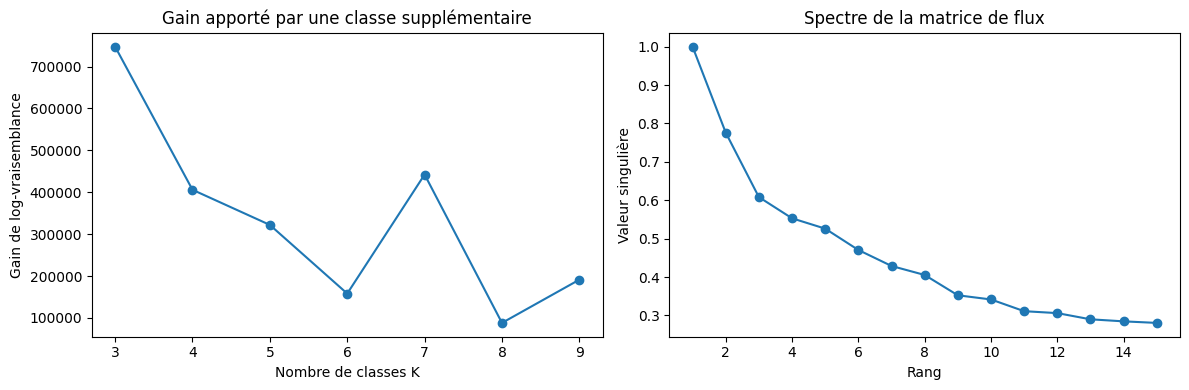

Gains : [747625, 405992, 322131, 158244, 442345, 88241, 191433]
Valeurs singulières : [1.    0.776 0.608 0.553 0.526 0.47  0.429 0.405 0.352 0.342]


In [149]:
import numpy as np
from sklearn.cluster import KMeans

# ---------- Matrice des flux ----------
stations = sorted(set(flux["Start station number"]) | set(flux["End station number"]))

index = {}
for i in range(len(stations)):
    index[stations[i]] = i

n = len(stations)
Y = np.zeros((n, n))

lignes = flux["Start station number"].map(index).values
colonnes = flux["End station number"].map(index).values
Y[lignes, colonnes] = flux["nb_trajets"].values

print("Matrice de flux :", Y.shape)


# ---------- Deux fonctions utilitaires ----------
def embed(Y, K):
    """Plongement spectral corrigé du degré : rôle émetteur + rôle récepteur."""
    d_out = Y.sum(axis=1).copy()
    d_in = Y.sum(axis=0).copy()
    d_out[d_out == 0] = 1
    d_in[d_in == 0] = 1
    L = Y / np.sqrt(np.outer(d_out, d_in))
    U, S, Vt = np.linalg.svd(L)
    E = np.concatenate([U[:, :K], Vt[:K, :].T], axis=1)
    normes = np.linalg.norm(E, axis=1)
    normes[normes == 0] = 1
    return E / normes[:, None]


def logvrais(Y, z, K):
    """Log-vraisemblance du SBM de Poisson corrigé du degré."""
    d_out = Y.sum(axis=1)
    d_in = Y.sum(axis=0)
    total = 0.0
    for k in range(K):
        ik = np.where(z == k)[0]
        ko = d_out[ik].sum()
        for l in range(K):
            il = np.where(z == l)[0]
            ki = d_in[il].sum()
            m = Y[np.ix_(ik, il)].sum()
            if m > 0 and ko > 0 and ki > 0:
                total = total + m * (np.log(m) - np.log(ko) - np.log(ki))
    return total


# ---------- Vraisemblance pour plusieurs K ----------
liste_K = range(2, 10)
vraisemblances = []

for K in liste_K:
    z = KMeans(n_clusters=K, n_init=20, random_state=42).fit_predict(embed(Y, K))
    vraisemblances.append(logvrais(Y, z, K))
    print("K =", K, "terminé")

gains = []
for i in range(1, len(vraisemblances)):
    gains.append(vraisemblances[i] - vraisemblances[i - 1])


# ---------- Deux diagnostics ----------
d_out = Y.sum(axis=1).copy()
d_in = Y.sum(axis=0).copy()
d_out[d_out == 0] = 1
d_in[d_in == 0] = 1
valeurs_sing = np.linalg.svd(Y / np.sqrt(np.outer(d_out, d_in)), compute_uv=False)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(list(liste_K)[1:], gains, marker="o")
plt.xlabel("Nombre de classes K")
plt.ylabel("Gain de log-vraisemblance")
plt.title("Gain apporté par une classe supplémentaire")

plt.subplot(1, 2, 2)
plt.plot(range(1, 16), valeurs_sing[:15], marker="o")
plt.xlabel("Rang")
plt.ylabel("Valeur singulière")
plt.title("Spectre de la matrice de flux")

plt.tight_layout()
plt.show()

print("Gains :", [round(g) for g in gains])
print("Valeurs singulières :", valeurs_sing[:10].round(3))

### Choix du nombre de classes

Aucun des deux diagnostics ne désigne un nombre de classes évident. Le gain de
vraisemblance décroît lentement — 747 600 pour la troisième classe, 406 000 pour la
quatrième — sans jamais s'effondrer, et il remonte même à K = 7, signe que l'estimation
devient instable au-delà. Le spectre de la matrice de flux décroît régulièrement de 1 à
0,34, sans rupture nette.

C'est un résultat en soi : le réseau ne se décompose pas en blocs nettement séparés. Le
seul ralentissement visible apparaît après la troisième valeur singulière, où les écarts
passent de 0,22 et 0,17 à 0,06, et c'est aussi le rang à partir duquel le gain de
vraisemblance est divisé par deux.

Nous retenons donc **K = 3** comme choix de synthèse à argumenter, et non comme un optimum
démontré par les critères.

Deux précisions de méthode. La partition est obtenue par plongement spectral de la matrice
de flux corrigée du degré, suivi d'un K-means ; la vraisemblance est ensuite évaluée sur
cette partition, elle n'est pas directement maximisée. Et la matrice Λ affichée ci-dessous
contient des volumes totaux échangés entre classes, non des intensités moyennes par couple
de stations.

### Estimation du modèle et interprétation des classes

On ajuste le modèle avec K = 3. L'estimation repose sur le plongement spectral de la
matrice de flux, corrigé du degré : chaque station est positionnée selon vers qui elle
envoie des vélos et de qui elle en reçoit, puis regroupée dans cet espace.

Trois sorties permettent d'interpréter le résultat : la **taille des classes**, la
**matrice des flux entre classes** — ses termes diagonaux mesurent le repli de chaque
classe sur elle-même, les autres les échanges entre groupes — et la comparaison entre
part des départs et part des arrivées, qui révèle d'éventuels rôles émetteur ou récepteur.

La carte permet enfin de vérifier si ces classes, estimées sans aucune information
géographique, présentent une cohérence spatiale.

Taille des classes :
classe
0    376
1    151
2    279
Name: count, dtype: int64
Part du trafic interne aux classes : 72.4 %


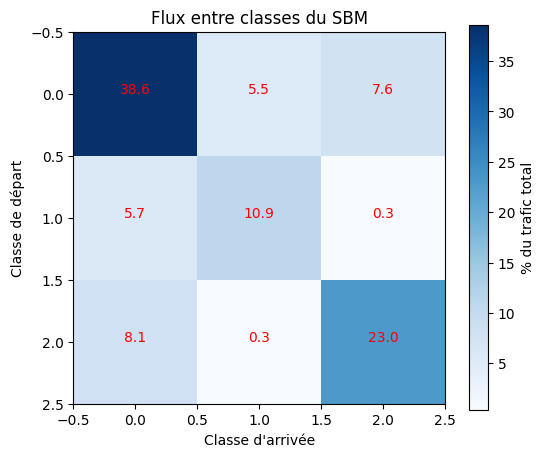

Classe 0 : départs 51.7 % | arrivées 52.3 %
Classe 1 : départs 16.9 % | arrivées 16.7 %
Classe 2 : départs 31.4 % | arrivées 31.0 %


In [150]:
K = 3

z_final = KMeans(n_clusters=K, n_init=50, random_state=42).fit_predict(embed(Y, K))

sbm = pd.DataFrame({"Station number": stations, "classe": z_final})
sbm = sbm.merge(noms_stations, left_on="Station number",
                right_on="terminal_name", how="left")

print("Taille des classes :")
print(sbm["classe"].value_counts().sort_index())


# ---------- Matrice des flux entre classes ----------
Lambda = np.zeros((K, K))

for k in range(K):
    ik = np.where(z_final == k)[0]
    for l in range(K):
        il = np.where(z_final == l)[0]
        Lambda[k, l] = Y[np.ix_(ik, il)].sum()

Lambda_pct = 100 * Lambda / Lambda.sum()

# Lambda contient des volumes totaux entre classes, pas des intensités moyennes
print("Part du trafic interne aux classes :",
      round(100 * np.trace(Lambda) / Lambda.sum(), 1), "%")

plt.figure(figsize=(6, 5))
plt.imshow(Lambda_pct, cmap="Blues")
plt.colorbar(label="% du trafic total")
plt.xlabel("Classe d'arrivée")
plt.ylabel("Classe de départ")
plt.title("Flux entre classes du SBM")

for k in range(K):
    for l in range(K):
        plt.text(l, k, round(Lambda_pct[k, l], 1), ha="center", color="red")

plt.show()


# ---------- Rôle émetteur / récepteur de chaque classe ----------
for k in range(K):
    part_out = 100 * Lambda[k, :].sum() / Lambda.sum()
    part_in = 100 * Lambda[:, k].sum() / Lambda.sum()
    print("Classe", k, ": départs", round(part_out, 1),
          "% | arrivées", round(part_in, 1), "%")


# ---------- Carte des classes ----------
import folium

coords = GPS_Point[["terminal_name", "latitude", "longitude"]]

geo_sbm = sbm.merge(coords, left_on="Station number",
                    right_on="terminal_name", how="left")
geo_sbm = geo_sbm.dropna(subset=["latitude", "longitude"])

couleurs_sbm = ["red", "blue", "green", "black", "purple"]

carte_sbm = folium.Map(location=[51.5074, -0.1278], zoom_start=12)

for i, row in geo_sbm.iterrows():
    c = int(row["classe"])
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3,
        color=couleurs_sbm[c],
        fill=True,
        fill_color=couleurs_sbm[c],
        fill_opacity=0.7,
        popup=f'{row["station_name"]} - classe {c}'
    ).add_to(carte_sbm)


# ---------- Légende ----------
legende = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
            background: white; border: 1px solid #ccc; border-radius: 4px;
            padding: 12px 14px; font-family: sans-serif; font-size: 13px;
            box-shadow: 0 1px 4px rgba(0,0,0,0.2);">
<b>Classes du SBM</b><br>
"""

for c in range(K):
    legende = legende + ('<span style="color:' + couleurs_sbm[c]
                         + '; font-size:18px;">&#9679;</span> Classe '
                         + str(c) + "<br>")

legende = legende + "</div>"

carte_sbm.get_root().html.add_child(folium.Element(legende))

carte_sbm.save("classes_sbm.html")
carte_sbm

### Ce que révèle le SBM

Les trois classes comptent 376, 279 et 151 stations. Chacune émet autant qu'elle reçoit,
à moins d'un point près : aucune n'est structurellement émettrice ou réceptrice.

La matrice des flux est très diagonale — **72,4 % du trafic reste à l'intérieur d'une
classe**. La classe 0 concentre à elle seule 52 % des mouvements, contre 31 % pour la
classe 2 et 17 % pour la classe 1, et ces deux dernières n'échangent presque rien entre
elles alors que toutes deux échangent avec la première.

La carte montre que ces classes forment trois zones géographiquement contiguës aux
frontières nettes : un centre qui concentre la moitié du trafic, et deux périphéries qui
ne communiquent qu'en passant par lui. Les classes traversent la Tamise là où se trouvent
les ponts, ce qui suggère qu'elles reflètent une accessibilité réelle plutôt qu'une
distance à vol d'oiseau.

La superposition des liaisons les plus fréquentées et des classes du SBM permet une
vérification indépendante de la partition. Si les classes correspondent à des zones fermées
sur elles-mêmes, les liaisons traversantes doivent être rares et concentrées là où les
zones se touchent.

In [151]:
import folium
import numpy as np

# ---------- 1. Les 200 liaisons les plus fortes, deux sens confondus ----------
# Les deux directions sont additionnées sur la totalité des liaisons AVANT
# la sélection : une présélection fausserait le classement des paires.
a_ser = flux["Start station number"].astype(str)
b_ser = flux["End station number"].astype(str)

petit = a_ser.where(a_ser <= b_ser, b_ser)
grand = b_ser.where(a_ser <= b_ser, a_ser)

flux_paires = pd.DataFrame({
    "a": petit.values,
    "b": grand.values,
    "nb": flux["nb_trajets"].values
})

paires = flux_paires.groupby(["a", "b"])["nb"].sum().reset_index()
paires = paires.rename(columns={"nb": "total"})
paires = paires.sort_values("total", ascending=False).head(200)


# ---------- 2. Coordonnées et classes des deux extrémités ----------
coords = GPS_Point[["terminal_name", "latitude", "longitude"]]

paires = paires.merge(coords, left_on="a", right_on="terminal_name", how="left")
paires = paires.rename(columns={"latitude": "lat_a", "longitude": "lon_a"})
paires = paires.drop(columns=["terminal_name"])

paires = paires.merge(coords, left_on="b", right_on="terminal_name", how="left")
paires = paires.rename(columns={"latitude": "lat_b", "longitude": "lon_b"})
paires = paires.drop(columns=["terminal_name"])

classe_station = {}
for i, row in sbm.iterrows():
    classe_station[str(row["Station number"])] = int(row["classe"])

paires["classe_a"] = paires["a"].map(classe_station)
paires["classe_b"] = paires["b"].map(classe_station)

paires = paires.dropna(subset=["lat_a", "lat_b", "classe_a", "classe_b"])


# ---------- 3. Couleurs et épaisseurs ----------
point_zone = ["#f2a5a5", "#a5bdf2", "#a5dcb5"]     # stations, en fond
ligne_zone = ["#c0392b", "#1f4e9c", "#1e7a4a"]     # liaisons internes
inter = "#000000"                                   # liaisons entre classes

largeurs = [1.5, 2.2, 3.0, 4.2, 6.0]
seuils = np.quantile(paires["total"], [0.2, 0.4, 0.6, 0.8])


# ---------- 4. Carte ----------
carte_sbm_flux = folium.Map(location=[51.5074, -0.1278], zoom_start=12)

geo_sbm = sbm.merge(coords, left_on="Station number",
                    right_on="terminal_name", how="left")
geo_sbm = geo_sbm.dropna(subset=["latitude", "longitude"])

for i, row in geo_sbm.iterrows():
    c = int(row["classe"])
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3.5,
        color=point_zone[c],
        fill=True,
        fill_color=point_zone[c],
        fill_opacity=1,
        weight=0
    ).add_to(carte_sbm_flux)

paires = paires.sort_values("total")

# Halo blanc sous chaque liaison
for i, row in paires.iterrows():
    t = row["total"]
    if t < seuils[0]:
        k = 0
    elif t < seuils[1]:
        k = 1
    elif t < seuils[2]:
        k = 2
    elif t < seuils[3]:
        k = 3
    else:
        k = 4

    folium.PolyLine(
        locations=[[row["lat_a"], row["lon_a"]], [row["lat_b"], row["lon_b"]]],
        color="#ffffff",
        weight=largeurs[k] + 2.5,
        opacity=0.9
    ).add_to(carte_sbm_flux)

# Liaisons par-dessus
for i, row in paires.iterrows():
    t = row["total"]
    if t < seuils[0]:
        k = 0
    elif t < seuils[1]:
        k = 1
    elif t < seuils[2]:
        k = 2
    elif t < seuils[3]:
        k = 3
    else:
        k = 4

    ca = int(row["classe_a"])
    cb = int(row["classe_b"])

    if ca == cb:
        couleur = ligne_zone[ca]
    else:
        couleur = inter

    folium.PolyLine(
        locations=[[row["lat_a"], row["lon_a"]], [row["lat_b"], row["lon_b"]]],
        color=couleur,
        weight=largeurs[k],
        opacity=1,
        popup=f'{int(t)} trajets'
    ).add_to(carte_sbm_flux)


# ---------- 5. Légende ----------
legende = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
            background: white; border: 1px solid #ccc; border-radius: 4px;
            padding: 12px 14px; font-family: sans-serif; font-size: 12px;
            box-shadow: 0 1px 4px rgba(0,0,0,0.2);">
<div style="font-weight: 600; margin-bottom: 8px;">Classes SBM et liaisons</div>
"""

for c in range(3):
    legende = legende + (
        '<div style="margin:3px 0;">'
        '<span style="display:inline-block;width:30px;height:4px;background:'
        + ligne_zone[c] + ';vertical-align:middle;margin-right:8px;"></span>'
        "liaison interne — classe " + str(c) + "</div>"
    )

legende = legende + (
    '<div style="margin:3px 0;">'
    '<span style="display:inline-block;width:30px;height:4px;background:'
    + inter + ';vertical-align:middle;margin-right:8px;"></span>'
    "liaison entre deux classes</div>"
    '<div style="margin-top:8px;color:#888;">Épaisseur = nombre de trajets<br>'
    "200 liaisons les plus fréquentées</div></div>"
)

carte_sbm_flux.get_root().html.add_child(folium.Element(legende))

carte_sbm_flux.save("classes_sbm_flux.html")


# ---------- 6. Le chiffre qui accompagne la carte ----------
interne = (paires["classe_a"] == paires["classe_b"]).sum()
print("Liaisons internes à une classe :", interne, "sur", len(paires),
      "soit", round(100 * interne / len(paires)), "%")

carte_sbm_flux



Liaisons internes à une classe : 191 sur 200 soit 96 %


### Un rapprochement avec la géographie administrative

Les trois classes estimées présentent une organisation géographique marquée, alors que
les coordonnées des stations n'ont jamais été utilisées pour construire la partition.
Elles recoupent approximativement les sous-régions du London Plan, le découpage officiel
de la Greater London Authority : la classe 1 correspond à l'est, la classe 0 au centre.
La classe 2 réunit des quartiers rattachés à l'ouest et d'autres au sud, l'emprise du
service, limitée au Londres intérieur, n'en retenant que les franges centrales, voisines
de part et d'autre de la Tamise.

Ce constat n'est pas une validation formelle du modèle : la correspondance n'a pas été
mesurée arrondissement par arrondissement. Il indique en revanche que la structure des
échanges suffit à retrouver une organisation spatiale cohérente.

## 4.3 Comparaison entre clustering vectoriel et clustering de graphe
Comparer les clusters obtenus sans prendre en compte le réseau avec les clusters obtenus par SBM.
- Les deux approches produisent-elles des groupes similaires ?
- Que capture le clustering vectoriel que le SBM ne capture pas, et inversement ?
 Quelle représentation semble la plus pertinente pour comprendre le fonctionnement du réseau ?

In [152]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ---------- Rassembler les deux partitions ----------
comp = Data_station.merge(sbm[["Station number", "classe"]],
                          on="Station number", how="inner")

print("Stations comparées :", len(comp))
print("ARI :", round(adjusted_rand_score(comp["cluster"], comp["classe"]), 3))
print("NMI :", round(normalized_mutual_info_score(comp["cluster"], comp["classe"]), 3))

print("--- Tableau croisé ---")
print(pd.crosstab(comp["cluster"], comp["classe"]))


# ---------- Que capte le SBM ? Profil comportemental de ses classes ----------
print("--- Profil des classes SBM sur les variables de la partie 3 ---")
print(comp.groupby("classe")[features].mean().round(3))

print("--- Rappel : profil des clusters de la partie 3 ---")
print(comp.groupby("cluster")[features].mean().round(3))


# ---------- Que capte le clustering vectoriel ? Dispersion géographique ----------
coords = GPS_Point[["terminal_name", "latitude", "longitude"]]

geo_comp = comp.merge(coords, left_on="Station number",
                      right_on="terminal_name", how="left")
geo_comp = geo_comp.dropna(subset=["latitude", "longitude"])

# Distance en kilomètres, chaque station pesant autant qu'une autre
for nom_partition in ["cluster", "classe"]:
    distances = []
    for g in sorted(geo_comp[nom_partition].unique()):
        sous = geo_comp[geo_comp[nom_partition] == g]
        lat_c = sous["latitude"].mean()
        lon_c = sous["longitude"].mean()
        dx = (sous["longitude"] - lon_c) * 111.32 * np.cos(np.radians(lat_c))
        dy = (sous["latitude"] - lat_c) * 111.32
        distances.extend(np.sqrt(dx ** 2 + dy ** 2).tolist())
    print(nom_partition, ": distance moyenne au centre du groupe =",
          round(np.mean(distances), 2), "km")

print("Stations sans coordonnées, exclues de ce calcul :",
      len(comp) - len(geo_comp))

Stations comparées : 804
ARI : -0.004
NMI : 0.04
--- Tableau croisé ---
classe     0    1    2
cluster               
0         19    1    4
1        179  111  189
2        121   12   48
3         55   27   38
--- Profil des classes SBM sur les variables de la partie 3 ---
        log_volume  avg_duration_start  prop_morning  prop_evening  \
classe                                                               
0            9.259              16.276         0.320         0.452   
1            9.034              16.657         0.295         0.461   
2            9.021              17.586         0.314         0.442   

        prop_weekend  imb_matin  imb_soir  daily_variability  \
classe                                                         
0              0.210     -0.004     0.021             13.161   
1              0.275      0.253    -0.144              9.423   
2              0.254      0.155    -0.093             10.035   

        hourly_variability  
classe                   

### Comparaison des deux approches

La concordance entre les deux partitions est très faible : l'indice de Rand ajusté vaut
−0,004 et l'information mutuelle normalisée 0,04. Le tableau croisé le montre directement :
le cluster résidentiel, qui rassemble à lui seul 479 stations, se répartit entre les trois
classes du SBM dans des proportions proches de leurs tailles respectives.

Les profils comportementaux des classes SBM sont resserrés — déséquilibre matinal entre
−0,004 et 0,25, part de week-end entre 21 et 28 % — là où les clusters de la partie 3
s'opposent sur des écarts deux fois plus larges. On distingue tout de même un léger
gradient : la classe centrale est un peu plus tertiaire, les deux classes périphériques
un peu plus résidentielles.

À l'inverse, les classes du SBM sont nettement plus compactes dans l'espace : la distance
moyenne d'une station au centre de son groupe vaut 2,29 km contre 3,93 km pour le
clustering vectoriel. Sept stations sans coordonnées sont exclues de ce calcul.

Les deux approches ne répondent donc pas à la même question. Le clustering vectoriel
regroupe les stations **qui se ressemblent** : deux quartiers résidentiels situés aux
extrémités de Londres se retrouvent ensemble sans jamais échanger un vélo. Le SBM regroupe
les stations **qui échangent**, et la partition obtenue présente ici une forte cohérence
géographique.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Données ----------
coords = GPS_Point[["terminal_name", "latitude", "longitude"]]

comp = Data_station.merge(sbm[["Station number", "classe"]],
                          on="Station number", how="inner")

geo = comp.merge(coords, left_on="Station number",
                 right_on="terminal_name", how="left")
geo = geo.dropna(subset=["latitude", "longitude"])

# Deux palettes distinctes : les deux partitions n'ont pas à se correspondre
couleurs_cluster = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
couleurs_classe = ["#6a3d9a", "#00918e", "#e6a700", "#c44e52"]

noms_cluster = ["Grands hubs", "Résidentiel", "Pôles d'emploi", "Loisir"]
noms_classe = ["Centre", "Est", "Ouest"]

aspect = 1 / np.cos(np.radians(51.5))


# ---------- Figure ----------
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# --- Carte 1 : clustering vectoriel ---
ax = axes[0]
for c in sorted(geo["cluster"].unique()):
    sous = geo[geo["cluster"] == c]
    ax.scatter(sous["longitude"], sous["latitude"], s=12,
               color=couleurs_cluster[int(c)],
               label=noms_cluster[int(c)] if int(c) < len(noms_cluster) else "Cluster " + str(c))

ax.set_aspect(aspect)
ax.set_title("Clustering vectoriel — profils d'usage", fontsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(fontsize=9, loc="lower left", frameon=True)

# --- Carte 2 : SBM ---
ax = axes[1]
for c in sorted(geo["classe"].unique()):
    sous = geo[geo["classe"] == c]
    ax.scatter(sous["longitude"], sous["latitude"], s=12,
               color=couleurs_classe[int(c)],
               label=noms_classe[int(c)] if int(c) < len(noms_classe) else "Classe " + str(c))

ax.set_aspect(aspect)
ax.set_title("SBM — structure des flux", fontsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(fontsize=9, loc="lower left", frameon=True)

# --- Tableau croisé ---
ax = axes[2]
croise = pd.crosstab(geo["cluster"], geo["classe"])

im = ax.imshow(croise.values, cmap="Greys")

ax.set_xticks(range(croise.shape[1]))
ax.set_xticklabels(noms_classe[:croise.shape[1]], fontsize=9)
ax.set_yticks(range(croise.shape[0]))
ax.set_yticklabels(noms_cluster[:croise.shape[0]], fontsize=9)
ax.set_xlabel("Classe SBM")
ax.set_ylabel("Cluster vectoriel")

for i in range(croise.shape[0]):
    for j in range(croise.shape[1]):
        ax.text(j, i, croise.values[i, j], ha="center", va="center",
                color="white" if croise.values[i, j] > croise.values.max() / 2 else "black",
                fontsize=11)

ari = adjusted_rand_score(geo["cluster"], geo["classe"])
ax.set_title("Croisement des deux partitions\nARI = " + str(round(ari, 3)), fontsize=12)

plt.tight_layout()
plt.savefig("comparaison_clusterings.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion générale

Les deux représentations décrivent le même réseau sous deux angles indépendants.

La **représentation vectorielle** décrit les rythmes d'usage. Elle distingue quatre profils
— résidentiel, tertiaire, grands hubs et récréatif — que l'on reconnaît à leurs
déséquilibres inverses entre le matin et le soir. Ces groupes sont dispersés dans toute la
ville et leurs frontières sont graduelles, notamment entre résidentiel et récréatif.

La **représentation par graphe** décrit l'organisation des échanges. Elle fait apparaître
trois zones où 72 % du trafic reste interne, et dont deux n'échangent presque rien
directement. Cette structure est fortement spatiale, sans qu'aucune coordonnée n'ait été
fournie au modèle : la portée limitée d'un trajet à vélo suffit à inscrire la géographie
dans la matrice des flux.

Aucune des deux ne se déduit de l'autre, et c'est ce qui les rend complémentaires. Pour
anticiper les besoins de rééquilibrage — quelles stations se vident, à quelle heure — la
représentation vectorielle est l'outil adapté. Pour comprendre le découpage fonctionnel du
service — quelles zones fonctionnent en autonomie, par où transitent les échanges — c'est
la représentation par graphe qu'il faut mobiliser.

## Limites et prolongements

**Limites.** Le nettoyage écarte environ 4,6 % des trajets, dont les boucles sur place qui
peuvent correspondre à des promenades réelles. Le référentiel géographique date de 2026 et
est appliqué à des trajets de 2025, ce qui explique les neuf identifiants sans
correspondance. Les profils et les anomalies relèvent d'une lecture exploratoire : les
seuils utilisés sont des choix, non des niveaux de risque établis. Enfin, les données ne
contiennent aucune information sur le stock de vélos disponibles ni sur les opérations de
rééquilibrage, ce qui limite l'interprétation des déséquilibres observés.

**Dimension temporelle.** L'analyse est menée à l'échelle de l'année. Les tables agrégées
par jour, par heure, par semaine et par mois ont été construites mais restent peu
exploitées. Une comparaison des profils horaires entre semaine et week-end, ou une
évolution des volumes moyens journaliers d'un mois à l'autre, permettrait d'aborder la
dimension d'évolution annoncée en introduction.

**Prolongements possibles.** Le SBM appliqué au graphe brut retrouve avant tout la
géographie. Pour dégager une structure moins triviale, il faudrait modéliser le flux
attendu entre deux stations en fonction de leurs volumes et de leur distance, puis
appliquer le modèle aux écarts à cette prédiction. Une seconde piste consisterait à
construire des graphes distincts par période — matin, soir, semaine, week-end — afin de
tester si certaines stations changent de rôle et si les classes restent stables dans le
temps.